<span style="color:steelblue; text-align: left">

# Segmentação de Clientes e Next Best Action
</span>

**Cientista de Dados**: Enio Rubens

Projeto de portfólio usando o dataset **Online Retail II** [Chen, 2012]. A análise transforma dados transacionais em segmentos de clientes com RFM e K-Means, práticas recorrentes em mineração de dados aplicada a varejo e CRM [Chen, Sain e Guo, 2012; Jain, 2010], e adiciona uma camada preditiva e prescritiva de **Next Best Action** orientada por probabilidade de recompra, simulação de incentivos e lucro esperado, alinhada à lógica de analytics prescritivo [Bertsimas e Kallus, 2019].

<span style="color:steelblue; text-align: left">

## Introdução
</span>

Nem todos os clientes possuem o mesmo valor para o negócio. Alguns compram com frequência, outros concentram alto valor em poucas compras, e parte da base passa longos períodos sem comprar. Essa heterogeneidade é um dos fundamentos da segmentação de mercado e do CRM analítico [Wedel e Kamakura, 2000; Rust e Verhoef, 2005].

A segmentação ajuda a identificar grupos com padrões semelhantes e permite transformar dados transacionais em ações de marketing, retenção e CRM [Wedel e Kamakura, 2000]. O projeto usa RFM, uma representação comportamental amplamente usada para relacionar histórico de compra, valor do cliente e decisões de relacionamento [Fader, Hardie e Lee, 2005; Chen, Sain e Guo, 2012]:

- **Recency:** tempo desde a última compra.
- **Frequency:** frequência de compra.
- **Monetary:** valor gasto pelo cliente.

<span style="color:steelblue; text-align: left">

## Objetivo de negócio
</span>

O objetivo é criar uma visão acionável da base de clientes: identificar grupos de maior valor, clientes fiéis, compradores ocasionais, clientes em risco e perfis de baixa prioridade. A saída final deve apoiar priorização de investimento, campanhas e relacionamento com clientes, conectando análise descritiva a decisões operacionais, como defendido em abordagens de CRM personalizado e analytics prescritivo [Rust e Verhoef, 2005; Bertsimas e Kallus, 2019].


<span style="color:steelblue; text-align: left">

## 1. Imports & Configuração
</span>

Todos os parâmetros operacionais estão centralizados na célula abaixo.
Para reexecutar o notebook com um cenário diferente — novo período, outro
budget ou número de segmentos — edite apenas essa célula e execute
`Kernel → Restart & Run All`.


In [1]:
from io import StringIO
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.multilang import set_language, t
set_language("pt")
from src.config import (
    DATA_PATH, EXPORT_PATH, RANDOM_STATE, N_CLUSTERS,
    PREDICTION_HORIZON_DAYS, HOLDOUT_FRACTION,
    BUDGET_TOTAL, MARGIN_RATE, INCENTIVE_CATALOGUE,
    SEGMENT_UPLIFT_MULTIPLIER,
)
from src.data import load_raw, clean, build_rfm
from src.segmentation import (
    KMeansClusterAdder, search_k, segment_names, validate_segment_names, rank01,
)
from src.prediction import (
    make_preprocessor, make_model_specs, make_repurchase_pipeline,
    evaluate_classifier, calibrate,
)
from src.prescriptive import (
    simulate_actions, select_best_action, build_recommendation,
    allocate_budget, build_budget_curve, sensitivity_analysis, build_crm_export,
)
from src.viz import (
    set_corporate_theme, PALETTE,
    hist, barh, lineplot, scatter, boxplot, budget_curves, fmt, compact,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)
%config InlineBackend.figure_format = 'retina'
set_corporate_theme()

# ── Global variables ──────────────────────────────────────────────────────
# Edit only this block to re-run the notebook with a different scenario.
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "UniqueProducts",
]
log_features = [
    "Frequency",
    "Monetary",
    "AverageTicket",
    "UniqueProducts",
]
numeric_predictors = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageTicket",
    "QuantityTotal",
    "UniqueProducts",
]
selected_k = N_CLUSTERS

<span style="color:steelblue; text-align: left">

## 2. Carregamento dos dados
</span>

A base é carregada com `pandas` a partir do dataset **Online Retail II**, disponibilizado pelo UCI Machine Learning Repository [Chen, 2012]. A inspeção inicial exibe amostra, estrutura, estatísticas descritivas, dimensões e percentual de valores ausentes, etapa consistente com boas práticas de preparação e diagnóstico inicial de dados [Kuhn e Johnson, 2013].


Antes de executar: configure `DATA_PATH` em `src/config.py` apontando para sua copia local de `data/online_retail.csv` (ou `online_retail_II.csv`, se este for o nome local do seu arquivo).


In [2]:
raw_df = load_raw(DATA_PATH)
display(raw_df.head())


Dataset limpo: 541.909 linhas e 8 colunas


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.00,United Kingdom


<span style="color:steelblue; text-align: left">

## 3. Entendimento inicial da base
</span>

Esta etapa verifica tipos de dados, variáveis numéricas e categóricas, além de problemas de qualidade como valores ausentes em `Customer ID` e `Description`. Esse diagnóstico é importante porque decisões de modelagem e limpeza dependem da semântica das variáveis, da presença de ausências e da consistência dos registros [Kuhn e Johnson, 2013].


In [3]:
buffer = StringIO()
raw_df.info(buf=buffer)
display(Markdown("```text\n" + buffer.getvalue() + "\n```"))

display(raw_df.describe(include="all").T)

missing = raw_df.isna().mean().mul(100).sort_values(ascending=False).reset_index().round(2)
missing.columns = ["Column", "Missing percentage"]
display(missing)


```text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

```

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.00,NaN,NaN,NaN,9.55,218.08,-80995.00,1.00,3.00,10.00,80995.00
InvoiceDate,541909,23260,10/31/11 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.00,NaN,NaN,NaN,4.61,96.76,-11062.06,1.25,2.08,4.13,38970.00
CustomerID,406829.00,NaN,NaN,NaN,15287.69,1713.60,12346.00,13953.00,15152.00,16791.00,18287.00
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Column,Missing percentage
0,CustomerID,24.93
1,Description,0.27
2,InvoiceNo,0.00
3,StockCode,0.00
4,Quantity,0.00
5,InvoiceDate,0.00
6,UnitPrice,0.00
7,Country,0.00


<span style="color:steelblue; text-align: left">

## 4. Limpeza e tratamento dos dados
</span>

A limpeza remove registros que não representam compras válidas para segmentação, preservando a coerência entre a unidade de análise, o cliente, e o comportamento de compra observado [Kuhn e Johnson, 2013; Chen, Sain e Guo, 2012]:

- Linhas sem `Customer ID`, pois não podem ser atribuídas a um cliente.
- Datas inválidas após conversão de `InvoiceDate`.
- Cancelamentos com `Invoice` iniciado por `C`, conforme documentação do dataset [Chen, 2012].
- Quantidades e preços menores ou iguais a zero, associados a devoluções, ajustes ou transações sem receita.
- Descrições nulas, para manter consistência em análises de produtos.

Também é criada a coluna `Revenue = Quantity * Price`, e `Customer ID` é convertido para texto sem decimal. Essa engenharia mantém o foco em medidas comportamentais observáveis, coerentes com modelos de segmentação de clientes por transações [Fader, Hardie e Lee, 2005].


In [4]:
clean_df = clean(raw_df)
display(clean_df.head())

,Etapa,Antes,Depois,Removidos,% removido
0,Remove missing Customer ID,541909,406829,135080,24.93
1,Convert InvoiceDate,406829,406829,0,0.00
2,Remove cancellations,406829,397924,8905,2.19
3,Remove Quantity <= 0,397924,397924,0,0.00
4,Remove Price <= 0,397924,397884,40,0.01
5,Remove missing Description,397884,397884,0,0.00


Dataset limpo: 397.884 linhas e 9 colunas
Clientes únicos: 4.338
Receita total: 8.911.407,90


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


<span style="color:steelblue; text-align: left">

## 5. Engenharia de atributos RFM
</span>

A data de referência é a última data da base mais um dia. A tabela final possui uma linha por cliente com `Recency`, `Frequency`, `Monetary`, `AverageTicket`, `QuantityTotal`, `UniqueProducts` e `CountryMode`. A tríade RFM resume recência, intensidade e valor de compra, dimensões clássicas para análise de base de clientes e CLV [Fader, Hardie e Lee, 2005; Chen, Sain e Guo, 2012].


In [6]:
rfm = build_rfm(clean_df)
display(rfm.head())
display(rfm.describe().T)


Data de referência: 2011-12-10
Tabela RFM: 4.338 clientes


,Customer ID,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts,CountryMode
0,12346,326,1,77183.60,77183.60,74215,1,United Kingdom
1,12347,2,7,4310.00,615.71,2458,103,Iceland
2,12348,75,4,1797.24,449.31,2341,22,Finland
3,12349,19,1,1757.55,1757.55,631,73,Italy
4,12350,310,1,334.40,334.40,197,17,Norway


,count,mean,std,min,25%,50%,75%,max
Recency,4338.00,92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,4338.00,4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,4338.00,2054.27,8989.23,3.75,307.41,674.49,1661.74,280206.02
AverageTicket,4338.00,419.17,1796.54,3.45,178.62,293.90,430.11,84236.25
QuantityTotal,4338.00,1191.29,5046.08,1.00,160.00,379.00,992.75,196915.00
UniqueProducts,4338.00,61.50,85.37,1.00,16.00,35.00,77.00,1787.00


<span style="color:steelblue; text-align: left">

## 6. Análise exploratória do RFM
</span>

As variáveis RFM tendem a ser assimétricas. A análise exploratória usa estatísticas e gráficos para revelar distribuição, concentração e possíveis valores extremos antes da modelagem, seguindo a tradição de EDA proposta por Tukey [Tukey, 1977]. Para leitura visual, alguns histogramas usam limite no percentil 99 apenas no gráfico, sem alterar os dados usados no clustering.


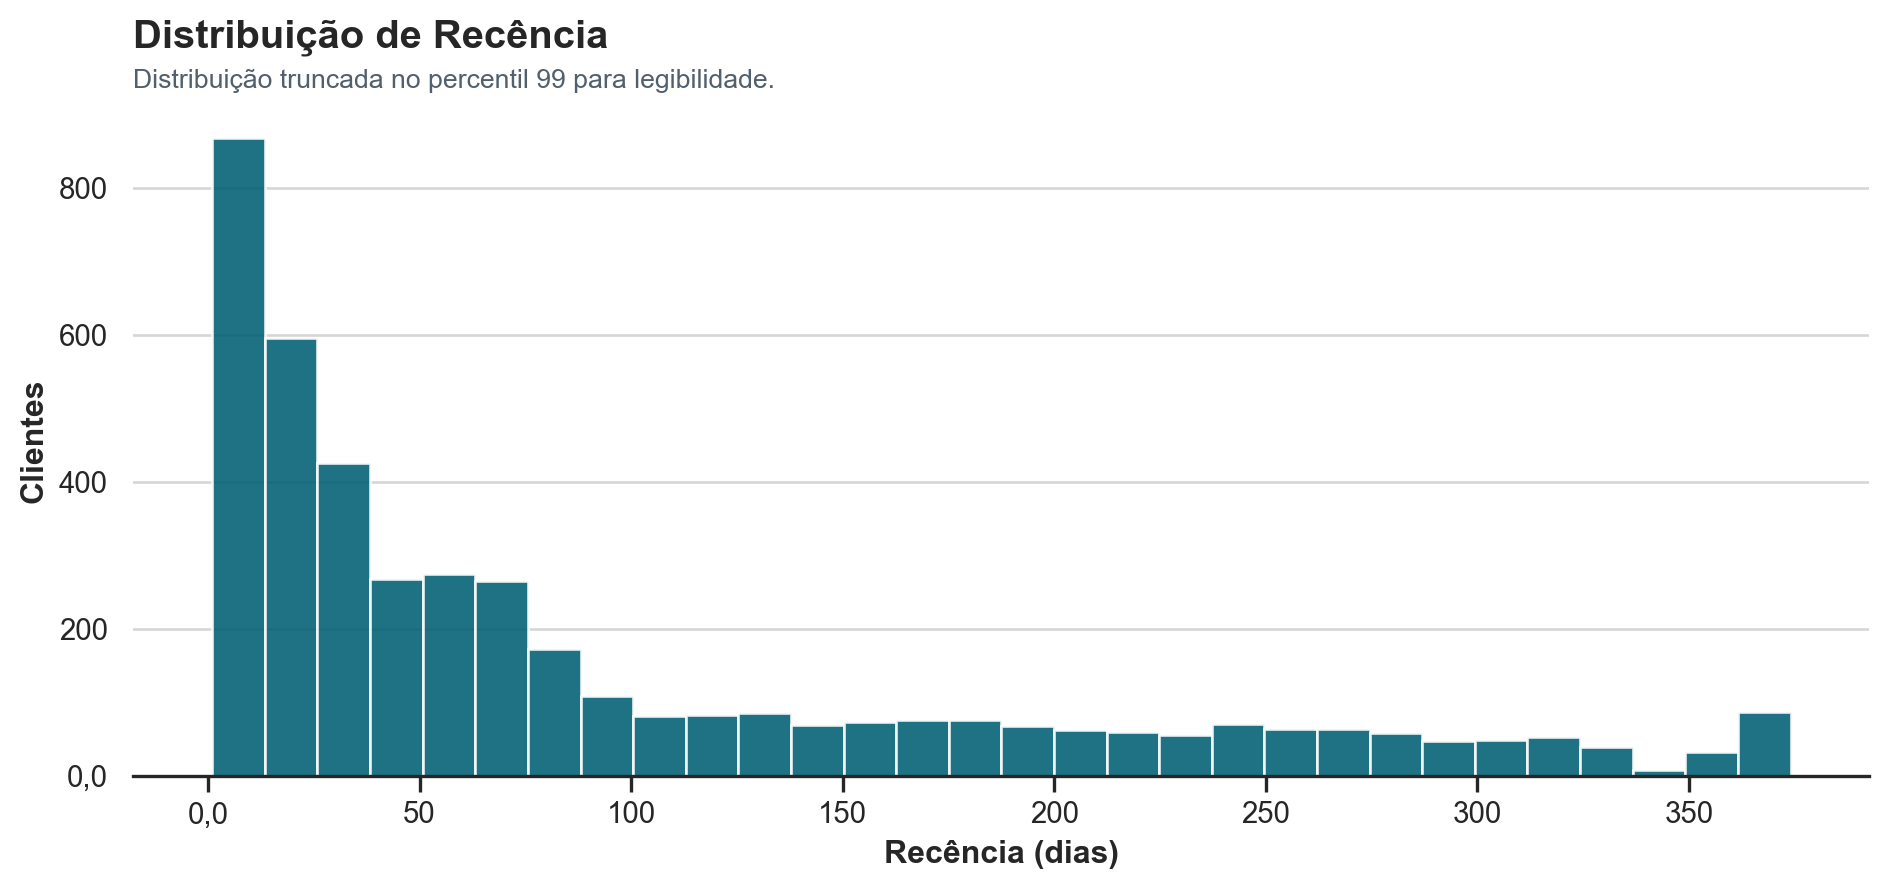

In [7]:
hist(
    rfm["Recency"],
    "Recency Distribution",
    "Distribution clipped at 99th percentile for readability.",
    "Recency (days)",
    PALETTE[0],
)


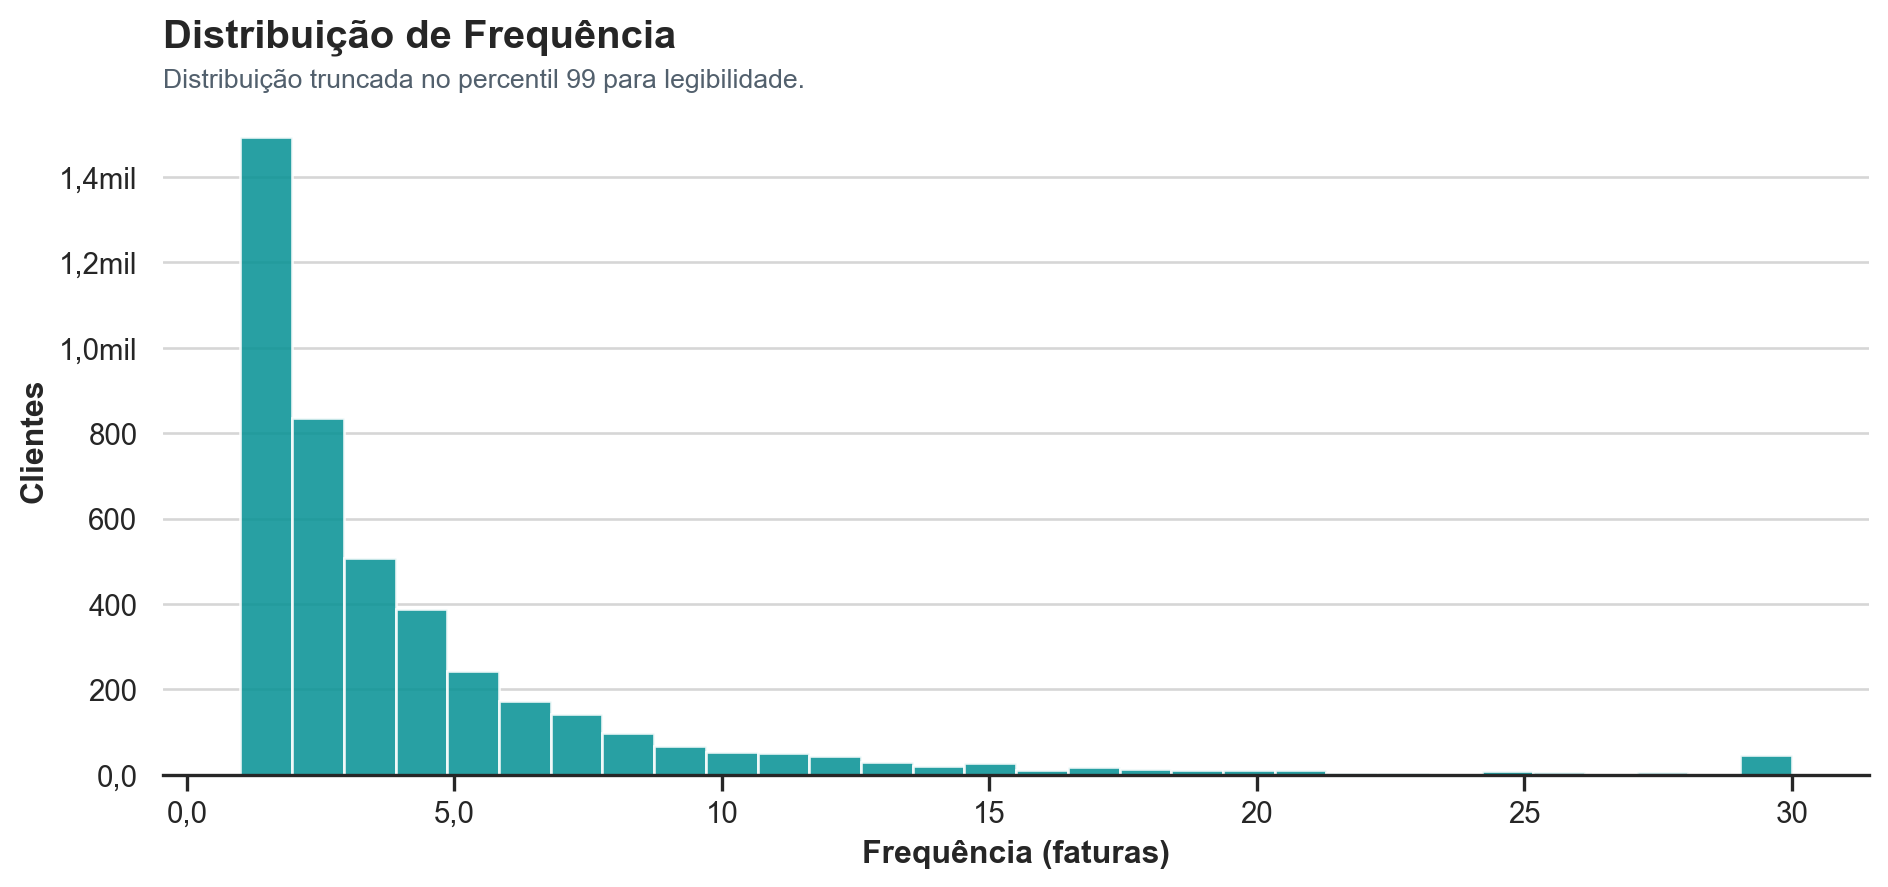

In [8]:
hist(
    rfm["Frequency"],
    "Frequency Distribution",
    "Distribution clipped at 99th percentile for readability.",
    "Frequency (invoices)",
    PALETTE[1],
    q=0.99,
)


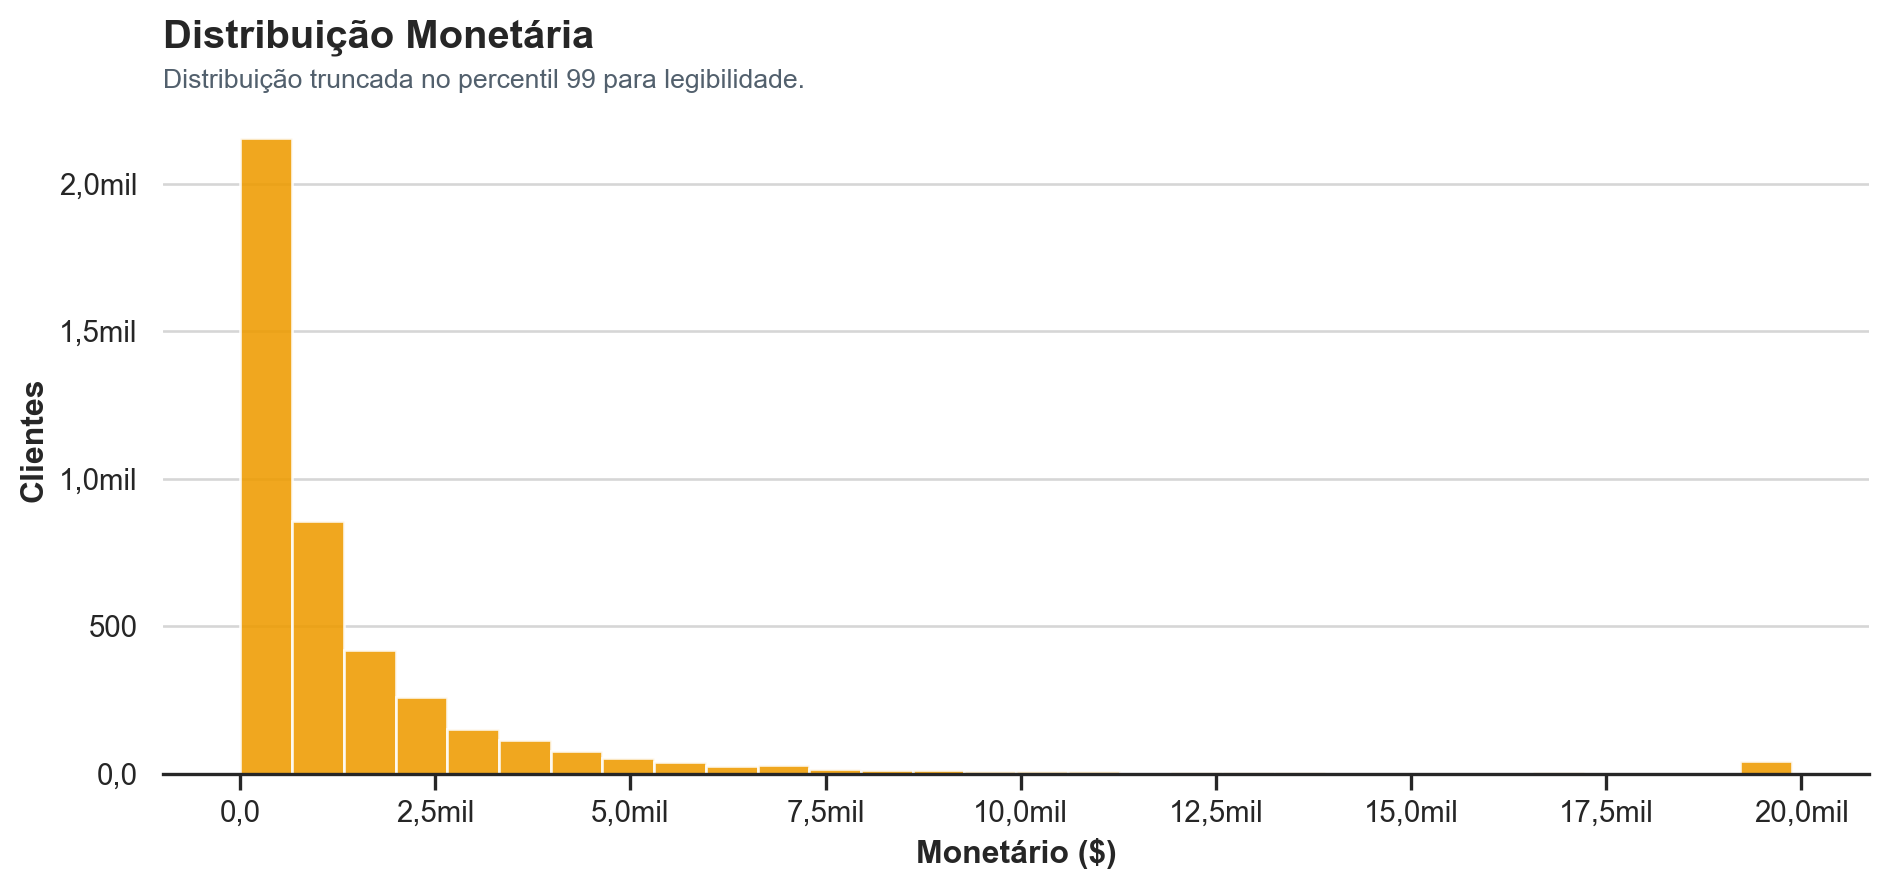

In [9]:
hist(
    rfm["Monetary"],
    "Monetary Distribution",
    "Distribution clipped at 99th percentile for readability.",
    "Monetary ($)",
    PALETTE[3],
    q=0.99,
)


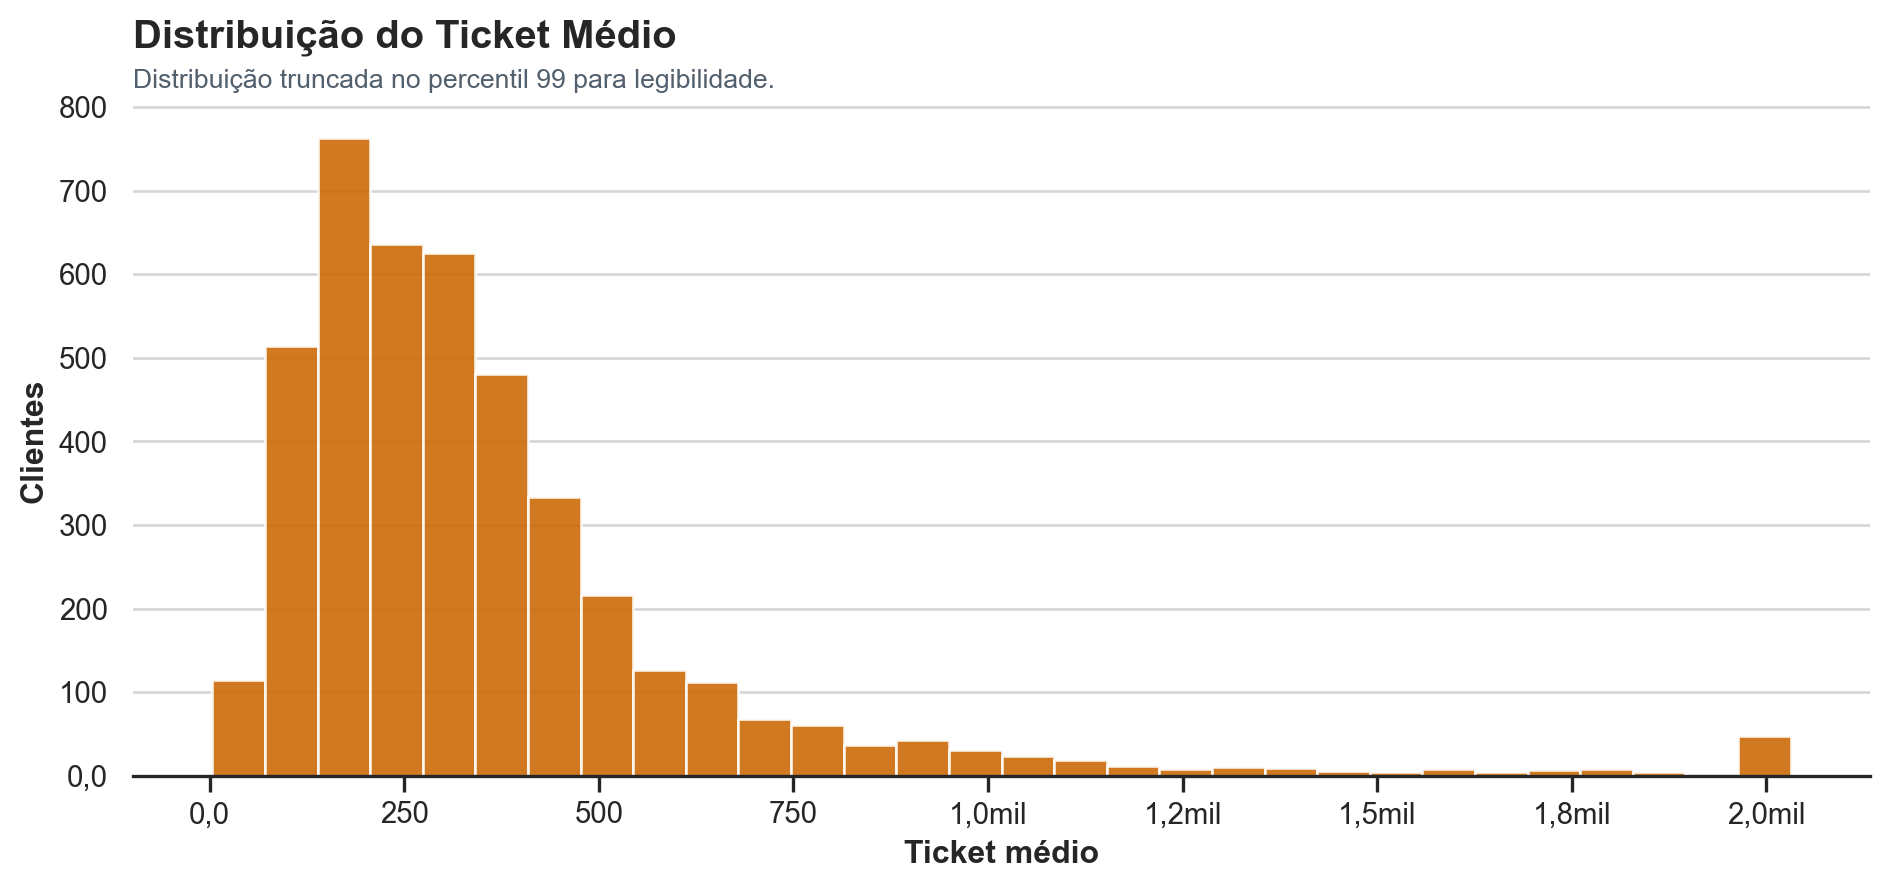

In [10]:
hist(
    rfm["AverageTicket"],
    "Average Ticket Distribution",
    "Distribution clipped at 99th percentile for readability.",
    "Average ticket",
    PALETTE[4],
    q=0.99,
)


<span style="color:steelblue; text-align: left">

### Insight (distribuicoes RFM):

</span>

A Recency se concentra em valores baixos com cauda longa a direita, indicando muitos compradores recentes e uma cauda de inatividade.
Frequency e Monetary sao fortemente assimetricas a direita, com minoria de clientes concentrando atividade e receita.
AverageTicket segue o mesmo padrao, com uma cauda premium que eleva medias acima das medianas.
Isso sustenta uma estrategia segmentada: base ampla de baixo/medio valor e tratamento direcionado para outliers de alto valor.


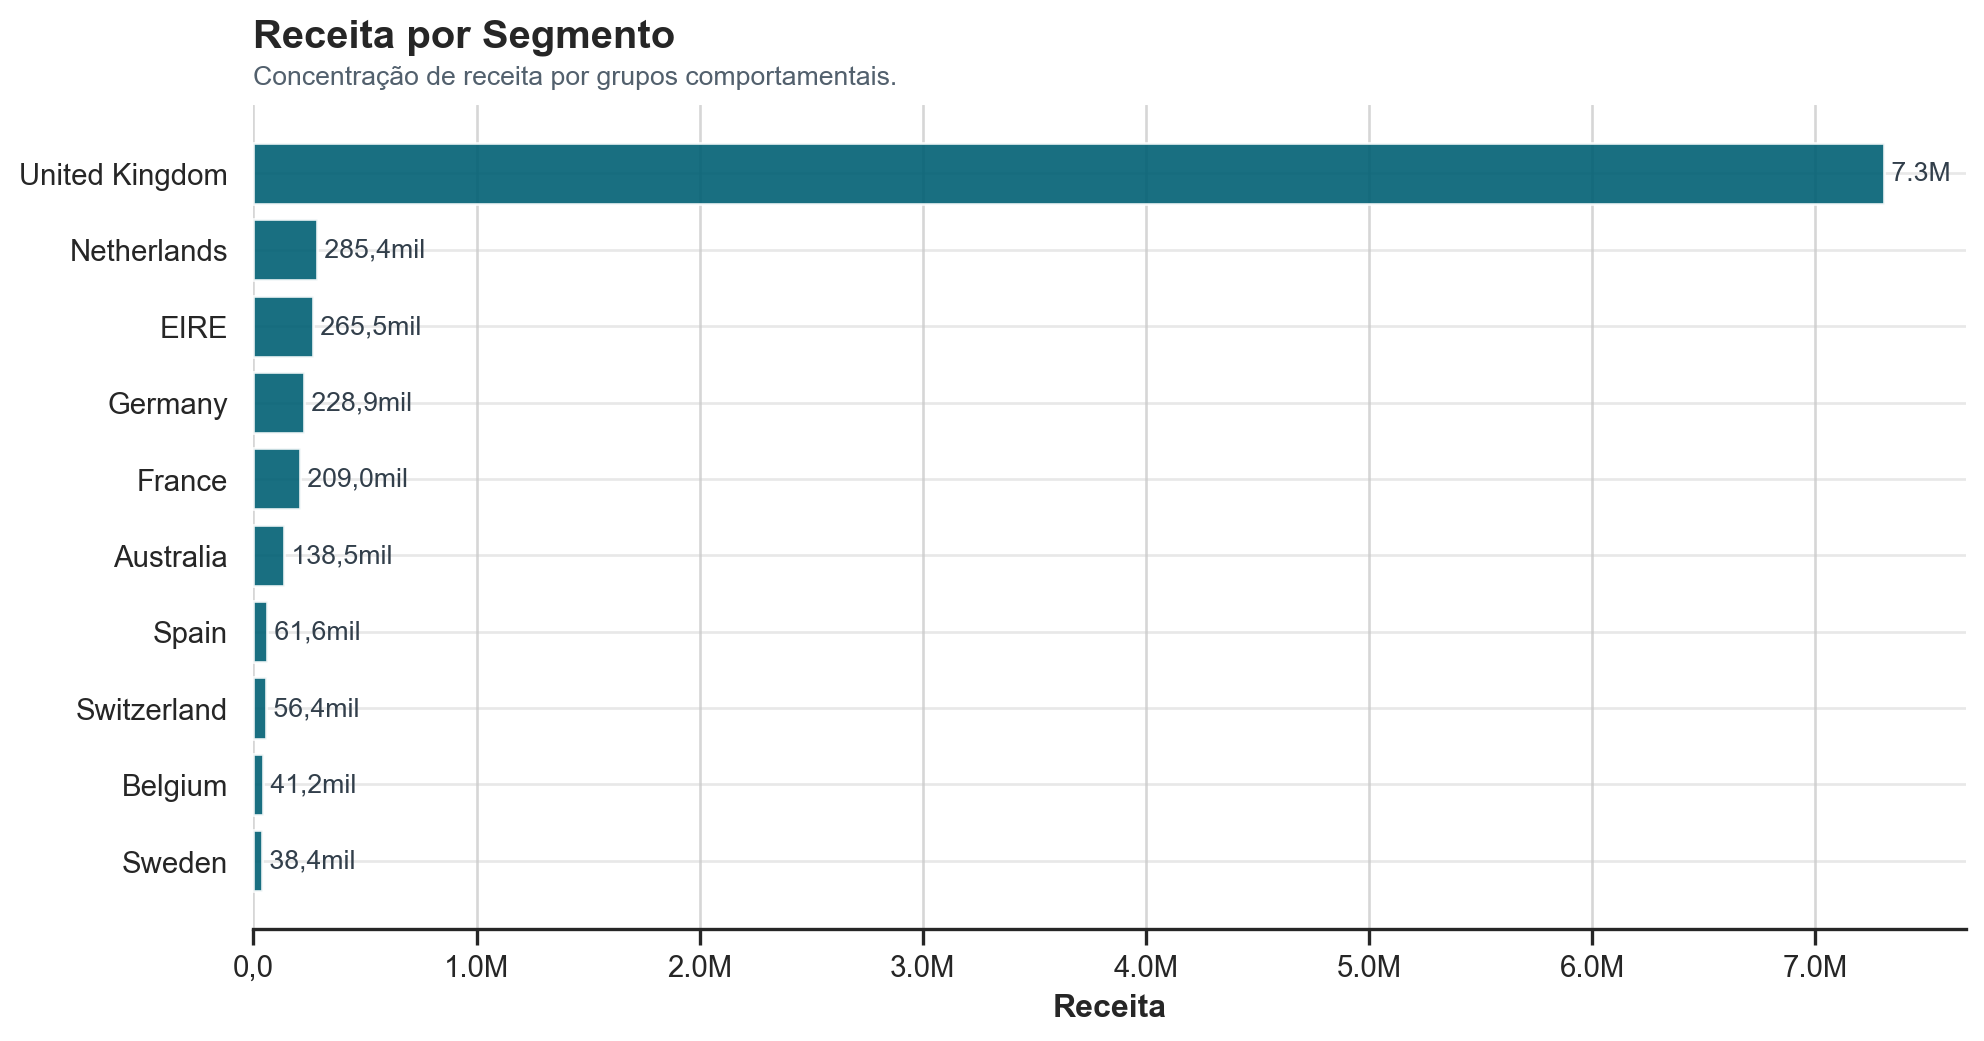

In [11]:
country_revenue = (
    clean_df.groupby("Country", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
    .head(10)
)
top_customers = rfm.nlargest(10, "Monetary")[["Customer ID", "Monetary"]]
barh(
    country_revenue.sort_values("Revenue"),
    "Country",
    "Revenue",
    "Revenue by Country",
    "Revenue concentration across top countries.",
    PALETTE[0],
)


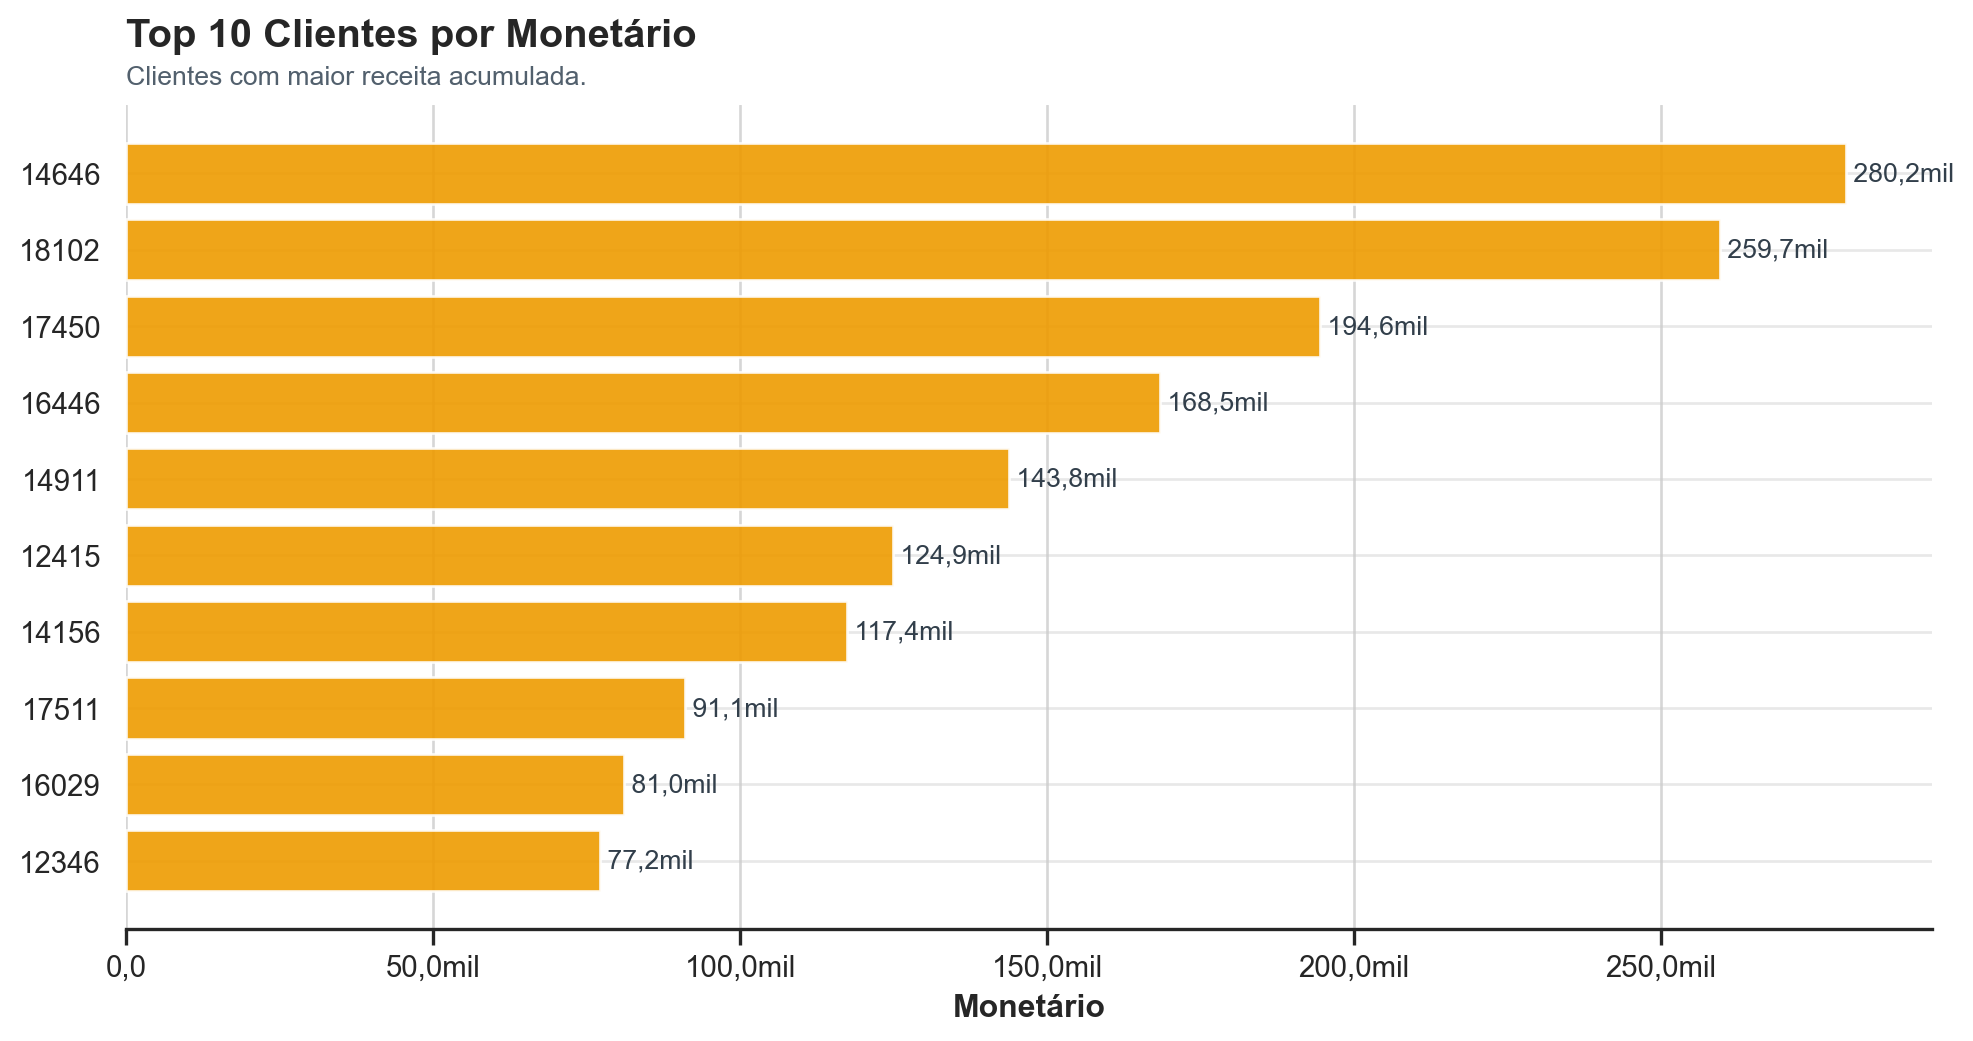

,Country,Revenue
35,United Kingdom,7308391.55
23,Netherlands,285446.34
10,EIRE,265545.90
14,Germany,228867.14
13,France,209024.05
0,Australia,138521.31
30,Spain,61577.11
32,Switzerland,56443.95
3,Belgium,41196.34
31,Sweden,38378.33


,Customer ID,Monetary
1689,14646,280206.02
4201,18102,259657.30
3728,17450,194550.79
3008,16446,168472.50
1879,14911,143825.06
55,12415,124914.53
1333,14156,117379.63
3771,17511,91062.38
2702,16029,81024.84
0,12346,77183.60


In [12]:
barh(
    top_customers.sort_values("Monetary"),
    "Customer ID",
    "Monetary",
    "Top 10 Customers by Monetary",
    "Customers with highest accumulated revenue.",
    PALETTE[3],
)
display(country_revenue)
display(top_customers)

<span style="color:steelblue; text-align: left">

### Insight (pais e concentração):

</span>

A receita esta concentrada em poucos paises, então priorização geografica pode aumentar eficiência de campanha.
A tabela de top clientes confirma concentração tipo power-law no nivel individual, com poucos clientes carregando grande volume monetario.
Essa concentração aumenta o upside de retenção para contas-chave, mas também eleva risco de dependência.
O resultado justifica combinar estrategia por segmento com priorização por conta.


<span style="color:steelblue; text-align: left">

## 7. Segmentação de clientes (K-Means)
</span>

As variáveis principais são `Recency`, `Frequency`, `Monetary`, `AverageTicket` e `UniqueProducts`. A transformação `log1p` é aplicada nas variáveis assimétricas para reduzir o peso de outliers [Kuhn e Johnson, 2013; Hastie, Tibshirani e Friedman, 2009]. Em seguida, os atributos são padronizados porque o K-Means usa distância euclidiana e é sensível à escala [MacQueen, 1967; Jain, 2010].

O modelo final é treinado com o número de clusters escolhido. O K-Means busca particionar observações em grupos próximos a centroides, minimizando distâncias internas [MacQueen, 1967; Lloyd, 1982].


In [13]:
cluster_df = rfm[features].copy()
for col in log_features:
    cluster_df[col] = np.log1p(cluster_df[col])

scaler = StandardScaler()
x_scaled = scaler.fit_transform(cluster_df)

print("Standardization used: StandardScaler")
display(cluster_df.head())


Standardization used: StandardScaler


,Recency,Frequency,Monetary,AverageTicket,UniqueProducts
0,326,0.69,11.25,11.25,0.69
1,2,2.08,8.37,6.42,4.64
2,75,1.61,7.49,6.11,3.14
3,19,0.69,7.47,7.47,4.30
4,310,0.69,5.82,5.82,2.89


In [14]:
from src.segmentation import fit_kmeans

labels, final_inertia = fit_kmeans(x_scaled, selected_k, n_init=20)
rfm["Cluster"] = labels.astype(int)

cluster_vars = [
    "Recency", "Frequency", "Monetary",
    "AverageTicket", "QuantityTotal", "UniqueProducts",
]
cluster_size = (
    rfm["Cluster"].value_counts().sort_index()
    .rename_axis("Cluster").reset_index(name=t("Customers (n)"))
)
cluster_mean   = rfm.groupby("Cluster")[cluster_vars].mean().round(2)
cluster_median = rfm.groupby("Cluster")[cluster_vars].median().round(2)
cluster_revenue = rfm.groupby("Cluster", as_index=False).agg(
    TotalRevenue=("Monetary", "sum")
)
cluster_revenue["RevenuePercentage"] = (
    cluster_revenue["TotalRevenue"] / cluster_revenue["TotalRevenue"].sum() * 100
).round(2)

display(cluster_size)
display(cluster_mean)
display(cluster_median)
display(cluster_revenue)

,Cluster,Clientes (n)
0,0,1142
1,1,449
2,2,670
3,3,448
4,4,1089
5,5,540


,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts
Cluster,,,,,,
0,55.91,1.86,434.58,255.38,276.84,28.52
1,16.16,17.41,11245.44,612.25,6324.33,196.29
2,271.27,1.35,372.05,295.37,202.65,21.94
3,137.26,1.49,135.76,97.84,107.60,7.61
4,36.36,5.37,1575.88,308.07,969.93,86.85
5,87.92,2.18,2480.89,1249.23,1429.28,61.84


,Recency,Frequency,Monetary,AverageTicket,QuantityTotal,UniqueProducts
Cluster,,,,,,
0,46.00,2.00,389.96,235.38,227.50,24.00
1,9.00,13.00,5346.23,450.99,3065.00,158.00
2,267.50,1.00,312.94,263.24,152.00,18.00
3,128.50,1.00,118.78,96.21,66.00,6.00
4,24.00,5.00,1421.29,298.97,829.00,75.00
5,71.00,2.00,1340.98,706.78,757.00,50.00


,Cluster,TotalRevenue,RevenuePercentage
0,0,496295.36,5.57
1,1,5049204.49,56.66
2,2,249271.17,2.80
3,3,60821.47,0.68
4,4,1716135.50,19.26
5,5,1339679.91,15.03


<span style="color:steelblue; text-align: left">

### Interpretacao (tabelas de cluster):

</span>

As diferenças entre medias e medianas indicam distribuicoes assimétricas dentro dos clusters, especialmente em Monetary e Frequency.
A participação de receita por cluster mostra que volume de clientes e valor econômico nao sao dimensões equivalentes.
Alguns clusters podem ser grandes e de baixo valor, enquanto clusters menores podem concentrar contribuição.
Por isso, nomenclatura e priorização devem ser ancoradas em impacto econômico, nao apenas tamanho.


<span style="color:steelblue; text-align: left">

## 8. Validação dos clusters (Elbow + Silhouette)
</span>

São testados valores de `k` entre 2 e 10. A análise usa `inertia`, relacionada à compactação interna típica do objetivo de mínimos quadrados do K-Means [Lloyd, 1982; Jain, 2010], e `silhouette_score`, para avaliar coesão e separação entre clusters [Rousseeuw, 1987]. A escolha final combina métrica e utilidade de negócio, já que um número matematicamente bom pode ser amplo demais para orientar ações [Wedel e Kamakura, 2000].


,k,inertia,silhouette_score
0,2,13156.48,0.33
1,3,10491.56,0.27
2,4,8863.36,0.27
3,5,7823.97,0.25
4,6,6993.07,0.25
5,7,6465.53,0.24
6,8,6002.72,0.22
7,9,5638.86,0.22
8,10,5329.29,0.22


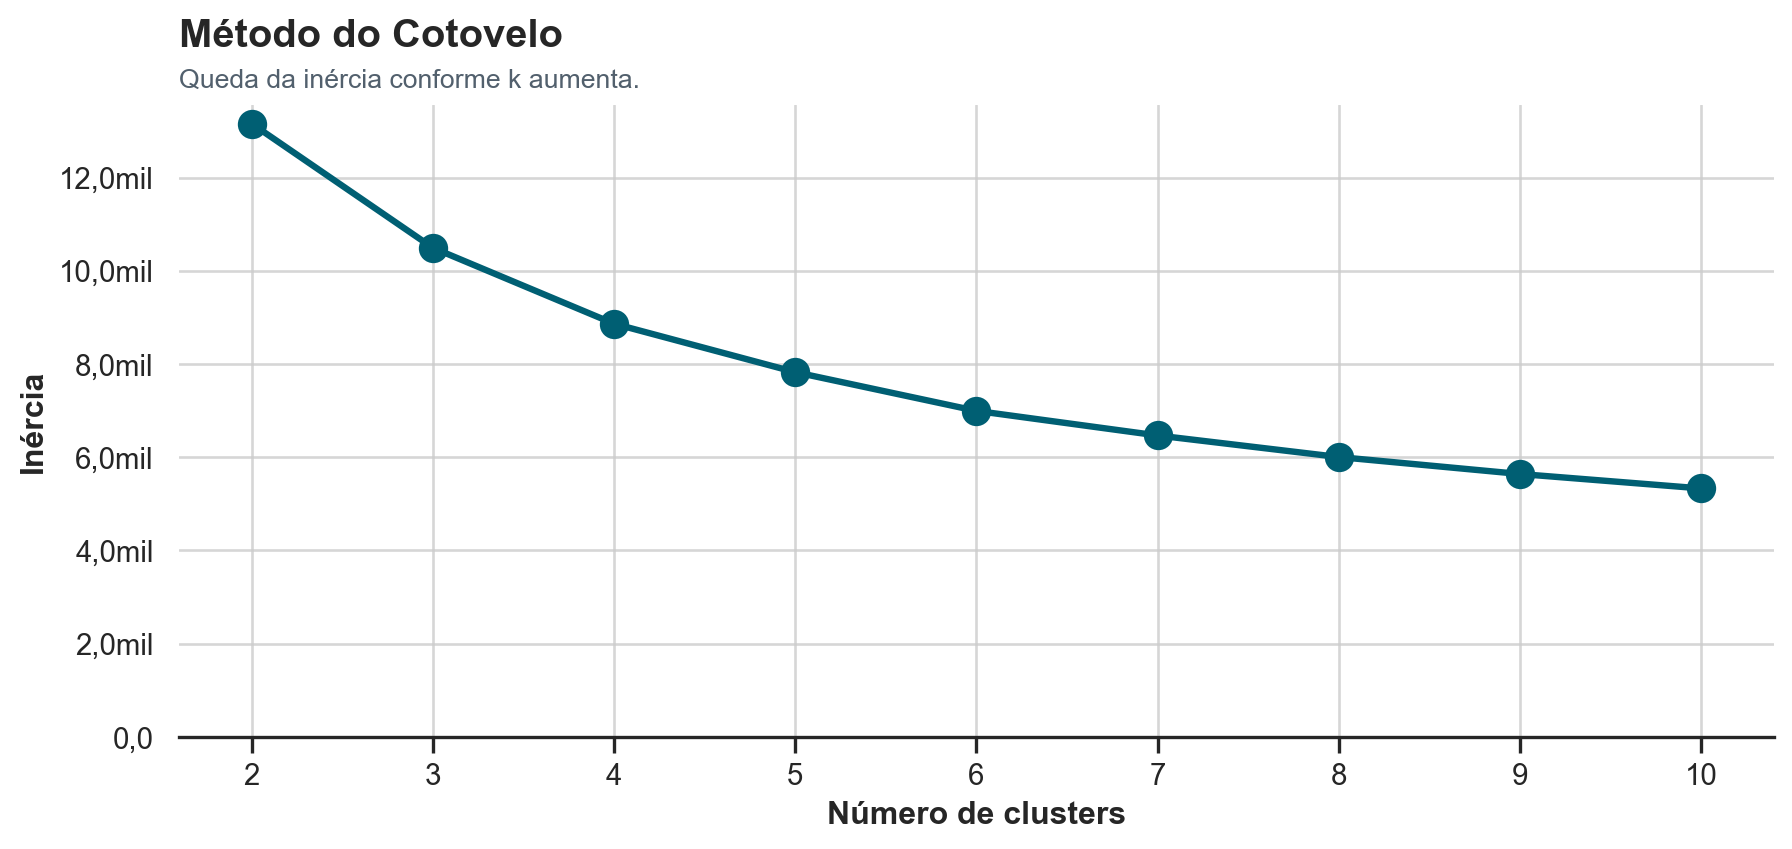

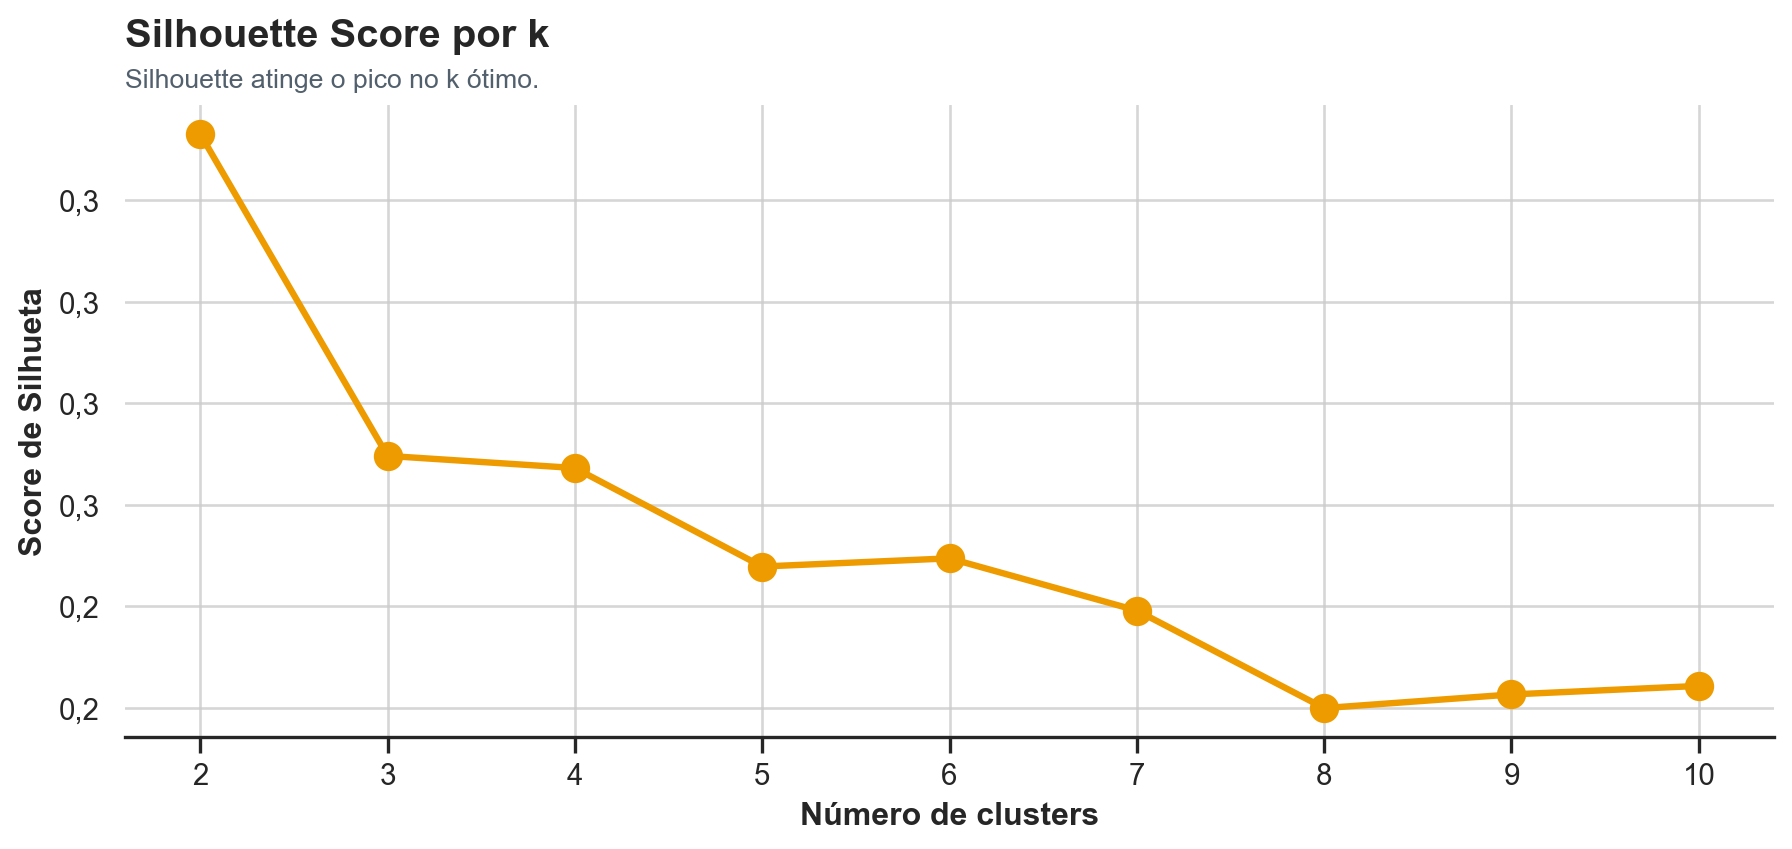

**Número de clusters escolhido: 6.**

A maior silhueta foi observada em `k=2`. `k=6` foi escolhido porque oferece segmentos mais acionáveis para Next Best Action, separando clientes de alto valor, clientes fiéis, compradores ocasionais, clientes de baixo valor, clientes inativos e clientes de alto valor em risco. A decisão prioriza equilíbrio entre qualidade estatística, interpretabilidade e utilidade de negócio.

In [15]:
k_metrics = search_k(x_scaled, k_range=range(2, 11))
display(k_metrics.round(4))

lineplot(k_metrics, "k", "inertia", "Elbow Method",
        "Inertia drop as k increases.", PALETTE[0], zero=True)
lineplot(k_metrics, "k", "silhouette_score", "Silhouette Score by k",
        "Silhouette peaks at the optimal k.", PALETTE[3])

best_k = int(k_metrics.loc[k_metrics["silhouette_score"].idxmax(), "k"])
text_template = t(
        "**Number of clusters chosen: {selected_k}.**\n\n"
        "The highest silhouette was observed at `k={best_k}`. "
        "`k={selected_k}` was chosen because it offers more actionable segments "
        "for Next Best Action, separating high-value customers, loyal customers, "
        "occasional buyers, low-value customers, inactive customers and at-risk "
        "high-value customers. The decision prioritizes a balance between statistical "
        "quality, interpretability and business utility."
)
text = text_template.format(selected_k=selected_k, best_k=best_k)
display(Markdown(text))


<span style="color:steelblue; text-align: left">

### Interpretacao (escolha de k):

</span>

A curva de elbow mostra retornos decrescentes de inercia apos a faixa intermediaria de k, enquanto a silhouette atinge pico proximo de k=6.
Um silhouette score de 0,38 indica separação moderada; valores abaixo de 0,5 normalmente sugerem sobreposição entre grupos.
Essa sobreposição e comum em dados comportamentais RFM, onde as fronteiras sao graduais e nao rigidas.
A escolha de k=6 foi deliberada para equilibrar interpretabilidade e granularidade acionável de negocio.


<span style="color:steelblue; text-align: left">

## 9. Perfilagem e nomenclatura dos segmentos
</span>

O número do cluster não tem significado de negócio. A interpretação abaixo transforma cada grupo em um segmento usando recência, frequência, receita, ticket médio e variedade de produtos. Essa tradução de agrupamentos estatísticos para segmentos gerenciais é central em segmentação de mercado aplicada [Wedel e Kamakura, 2000; Chen, Sain e Guo, 2012].

As visualizações conectam padrões de frequência, valor, recência, receita e tamanho dos segmentos. Gráficos exploratórios ajudam a validar se os grupos são interpretáveis [Tukey, 1977; Rousseeuw, 1987]. A leitura deve considerar que menor `Recency` representa compra mais recente.


In [16]:
ACTIONS = {
    "Champions":          "Offer VIP program, early access and exclusive benefits.",
    "High Value at Risk": "Prioritize reactivation campaigns and personalized offers.",
    "Loyal Customers":    "Encourage cross-sell and bundles.",
    "Occasional Buyers":  "Second-purchase campaigns and low-cost coupons.",
    "Low Value":          "Low-cost marketing automation.",
    "Inactive Customers": "Targeted reactivation or low priority.",
}

profile = rfm.groupby("Cluster").agg(
    Cluster=("Cluster", "first"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    AverageTicket=("AverageTicket", "mean"),
    UniqueProducts=("UniqueProducts", "mean"),
    TotalRevenue=("Monetary", "sum"),
    Customers=("Customer ID", "count"),
).reset_index(drop=True)
profile["RevenuePercentage"] = (
    profile["TotalRevenue"] / profile["TotalRevenue"].sum() * 100
)

names = segment_names(profile)
validate_segment_names(profile, names)

profile["SegmentName"] = profile["Cluster"].map(names)
rfm["SegmentName"]    = rfm["Cluster"].map(names)
rfm["NextBestAction"] = rfm["SegmentName"].map(ACTIONS)

segment_table = profile.sort_values("TotalRevenue", ascending=False)
display(segment_table)

,Cluster,Recency,Frequency,Monetary,AverageTicket,UniqueProducts,TotalRevenue,Customers,RevenuePercentage,SegmentName
1,1,16.16,17.41,11245.44,612.25,196.29,5049204.49,449,56.66,Champions
4,4,36.36,5.37,1575.88,308.07,86.85,1716135.50,1089,19.26,Loyal Customers
5,5,87.92,2.18,2480.89,1249.23,61.84,1339679.91,540,15.03,High Value at Risk
0,0,55.91,1.86,434.58,255.38,28.52,496295.36,1142,5.57,Occasional Buyers
2,2,271.27,1.35,372.05,295.37,21.94,249271.17,670,2.80,Inactive Customers
3,3,137.26,1.49,135.76,97.84,7.61,60821.47,448,0.68,Low Value


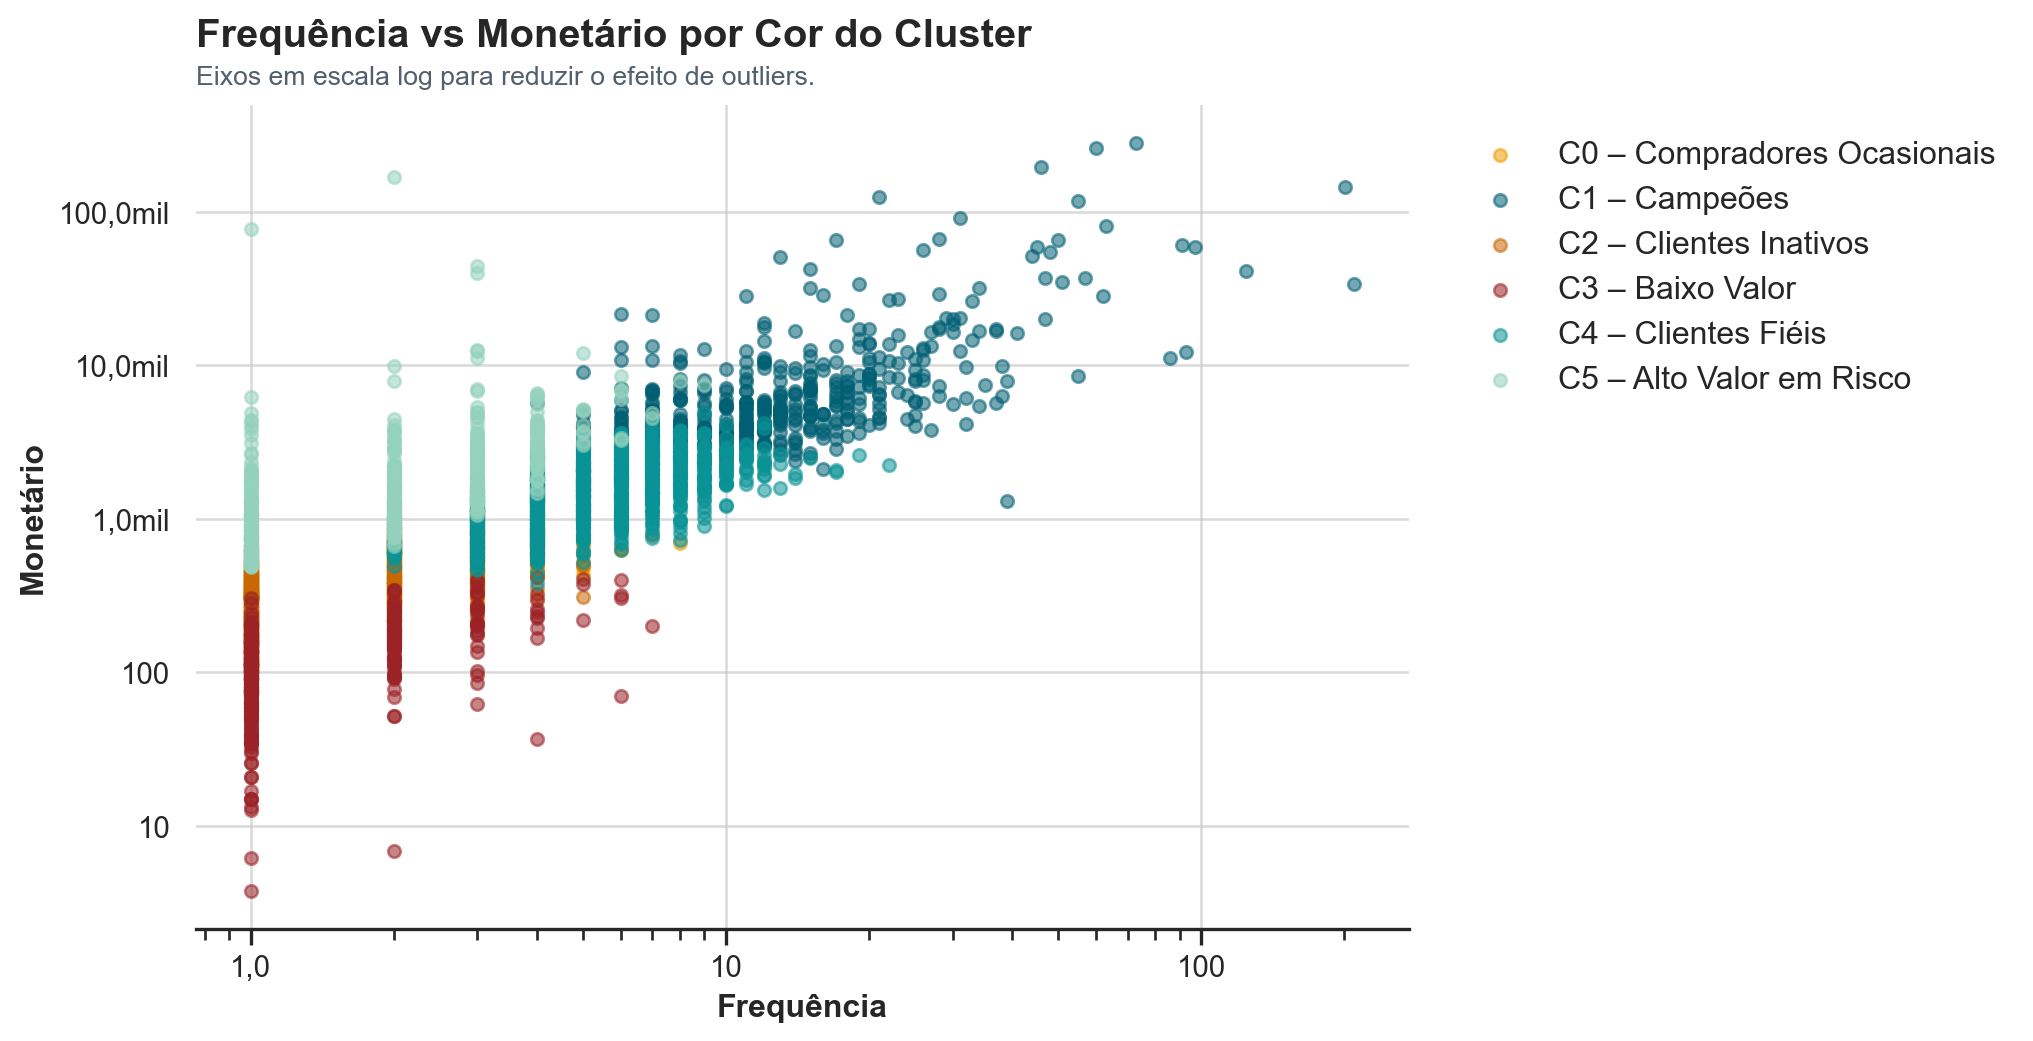

In [17]:
order = segment_table["Cluster"].tolist()
cluster_colors = {cl: PALETTE[i % len(PALETTE)] for i, cl in enumerate(order)}

scatter(rfm, "Frequency", "Monetary",
        "Frequency vs Monetary by Cluster Color",
        "Axes in log scale to reduce outlier effect.",
        cluster_colors, logx=True, logy=True)


<span style="color:steelblue; text-align: left">

### Interpretacao (Frequency vs Monetary):

</span>

Em escala log-log, os clusters se separam principalmente por nivel de gasto e cadencia de compra, não por um único corte linear.
A região superior direita concentra clientes de alta frequência e alto monetário, consistente com segmentos de relacionamento premium.
Clusters de baixa frequência e baixo monetário formam a base operacional densa e pedem táticas de baixo custo ou reativação.
Este gráfico e crítico para validar que a segmentação captura comportamentos economicamente distintos antes da predição.


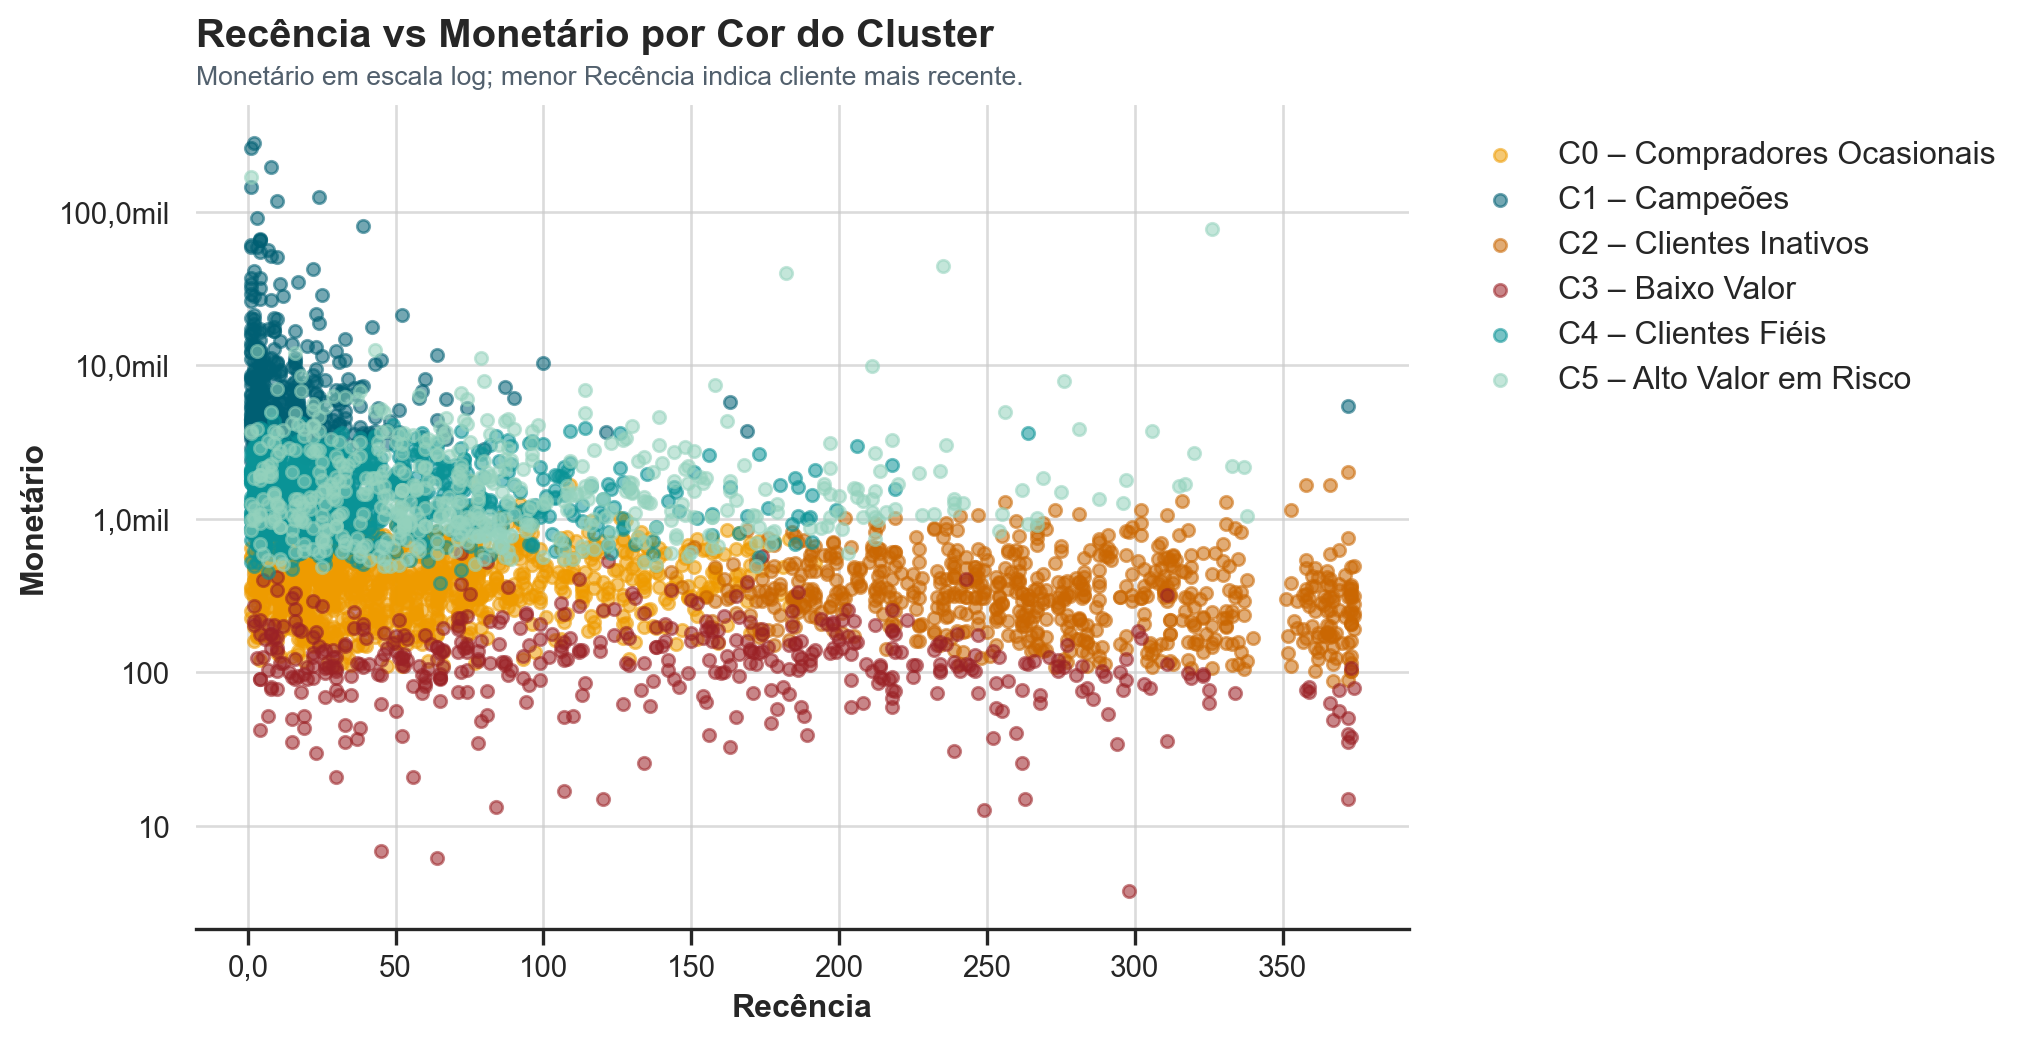

In [18]:
scatter(rfm, "Recency", "Monetary",
        "Recency vs Monetary by Cluster Color",
        "Monetary in log scale; lower Recency means more recent customer.",
        cluster_colors, logy=True)


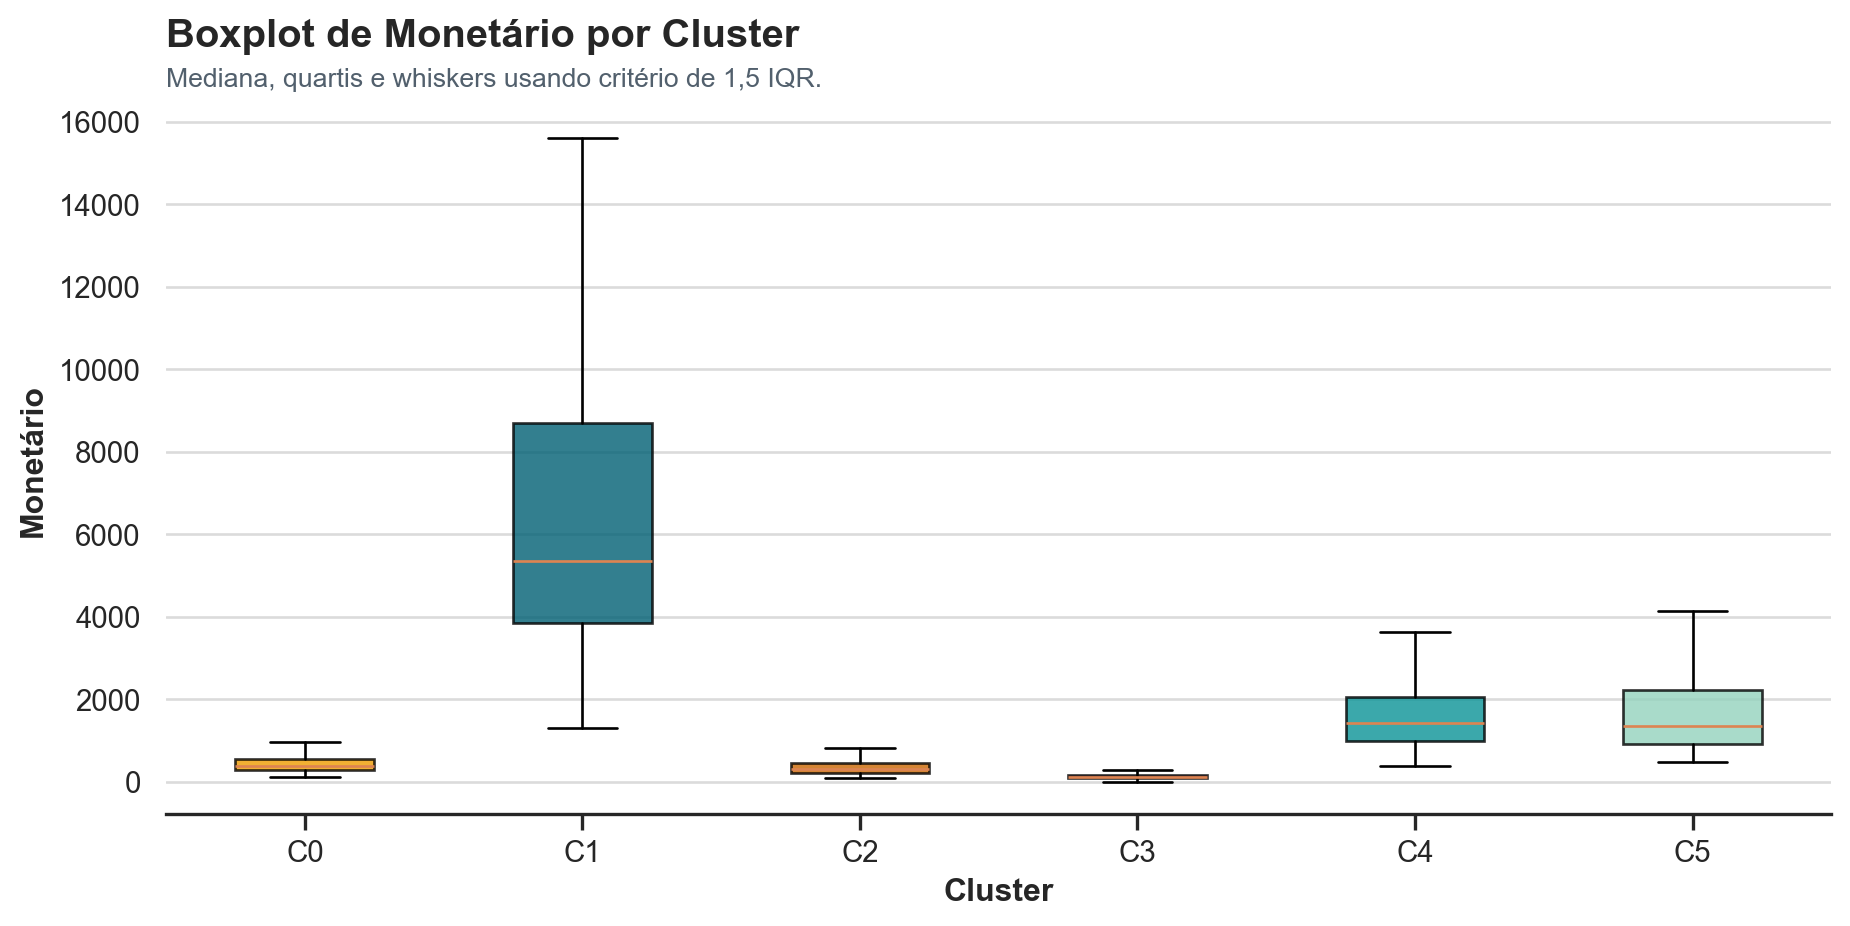

In [19]:
boxplot(rfm, "Cluster", "Monetary",
        "Monetary Boxplot by Cluster",
        "Median, quartiles and whiskers using 1.5 IQR criterion.",
        cluster_colors)

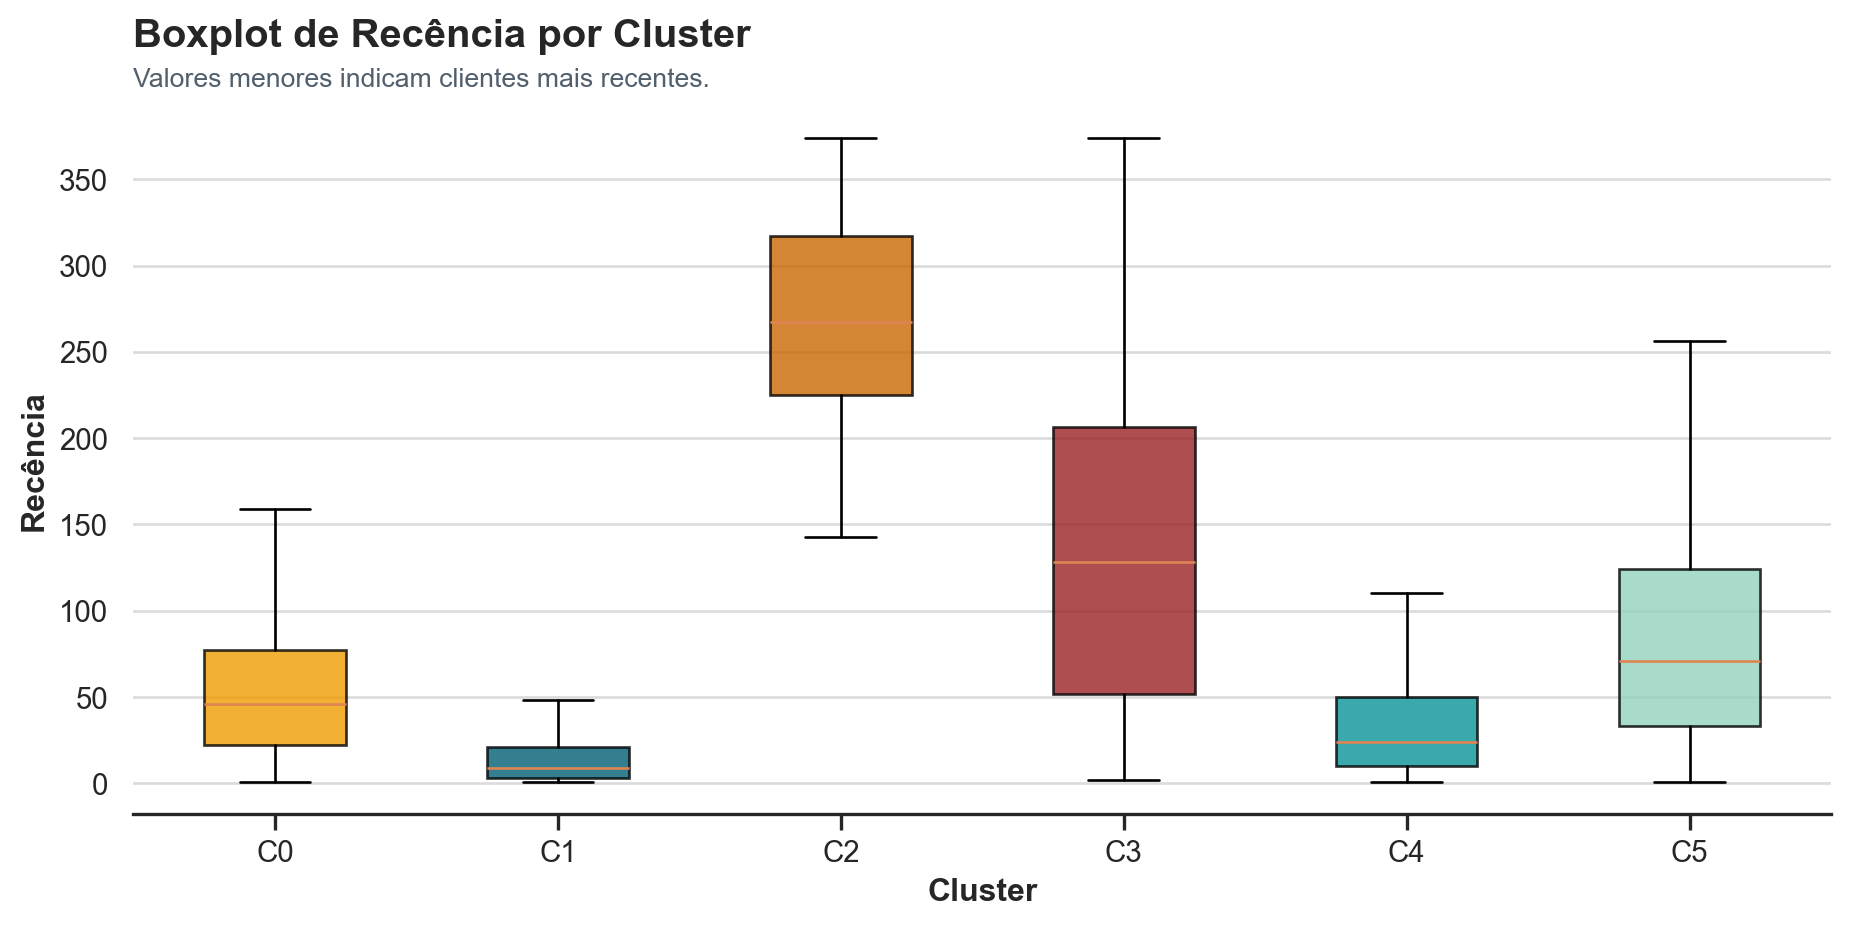

In [20]:
boxplot(rfm, "Cluster", "Recency",
        "Recency Boxplot by Cluster",
        "Lower values indicate more recent customers.",
        cluster_colors)

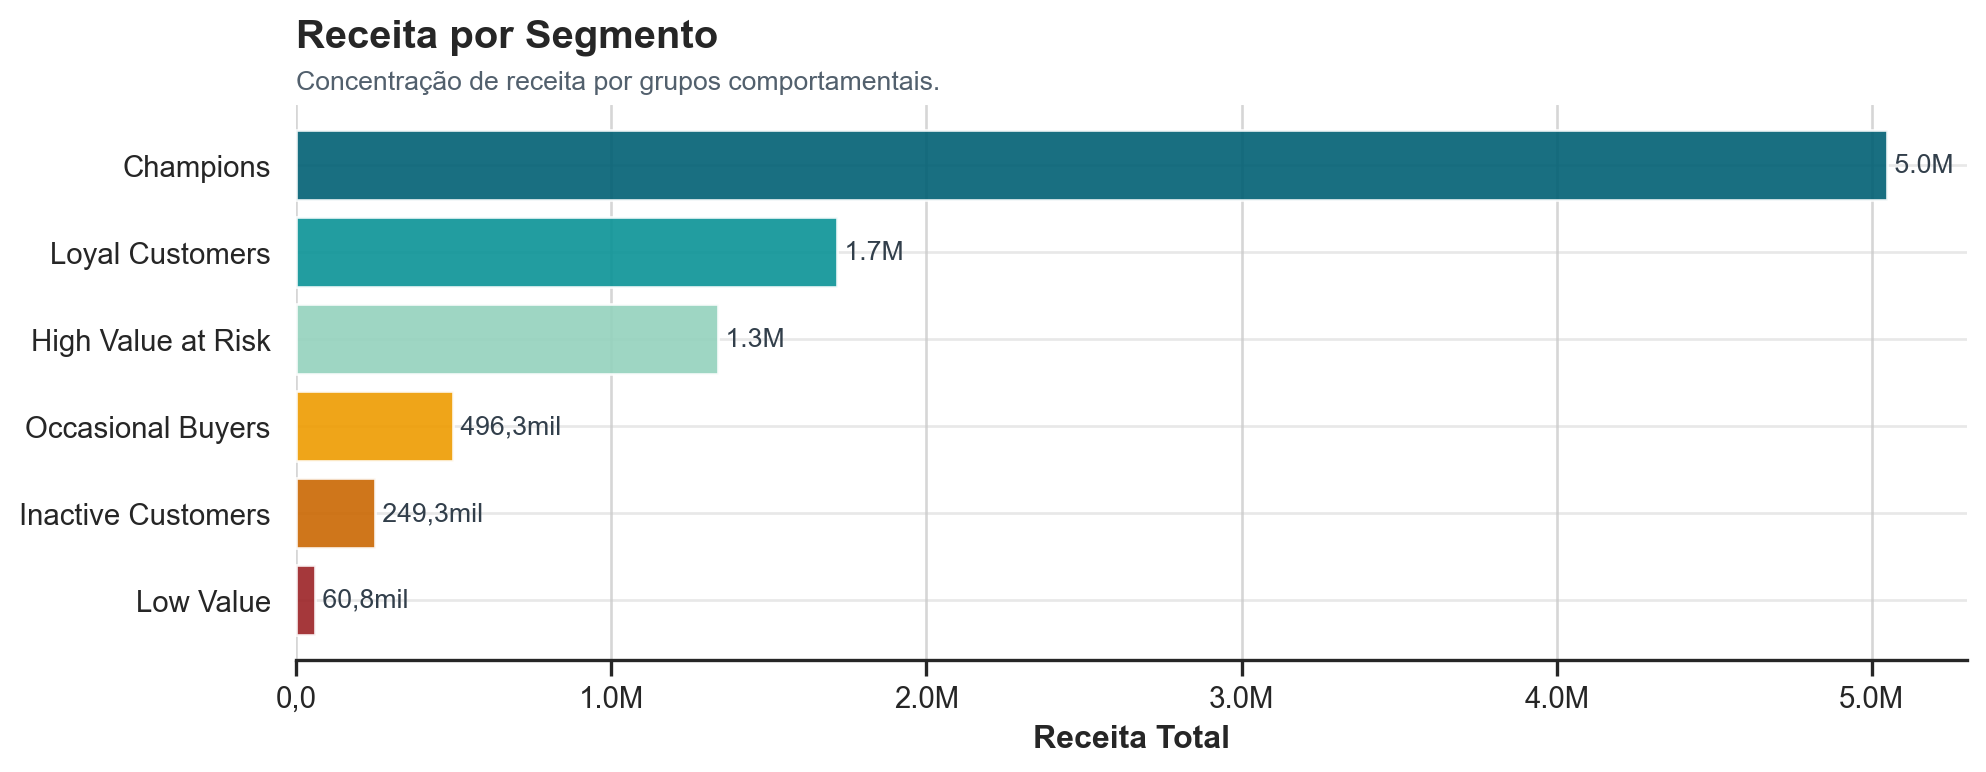

In [21]:
barh(
        profile.sort_values("TotalRevenue"),
        "SegmentName", "TotalRevenue",
        "Revenue by Segment",
        "Revenue concentration across behavioural groups.",
        color_col="Cluster", cmap=cluster_colors,
)

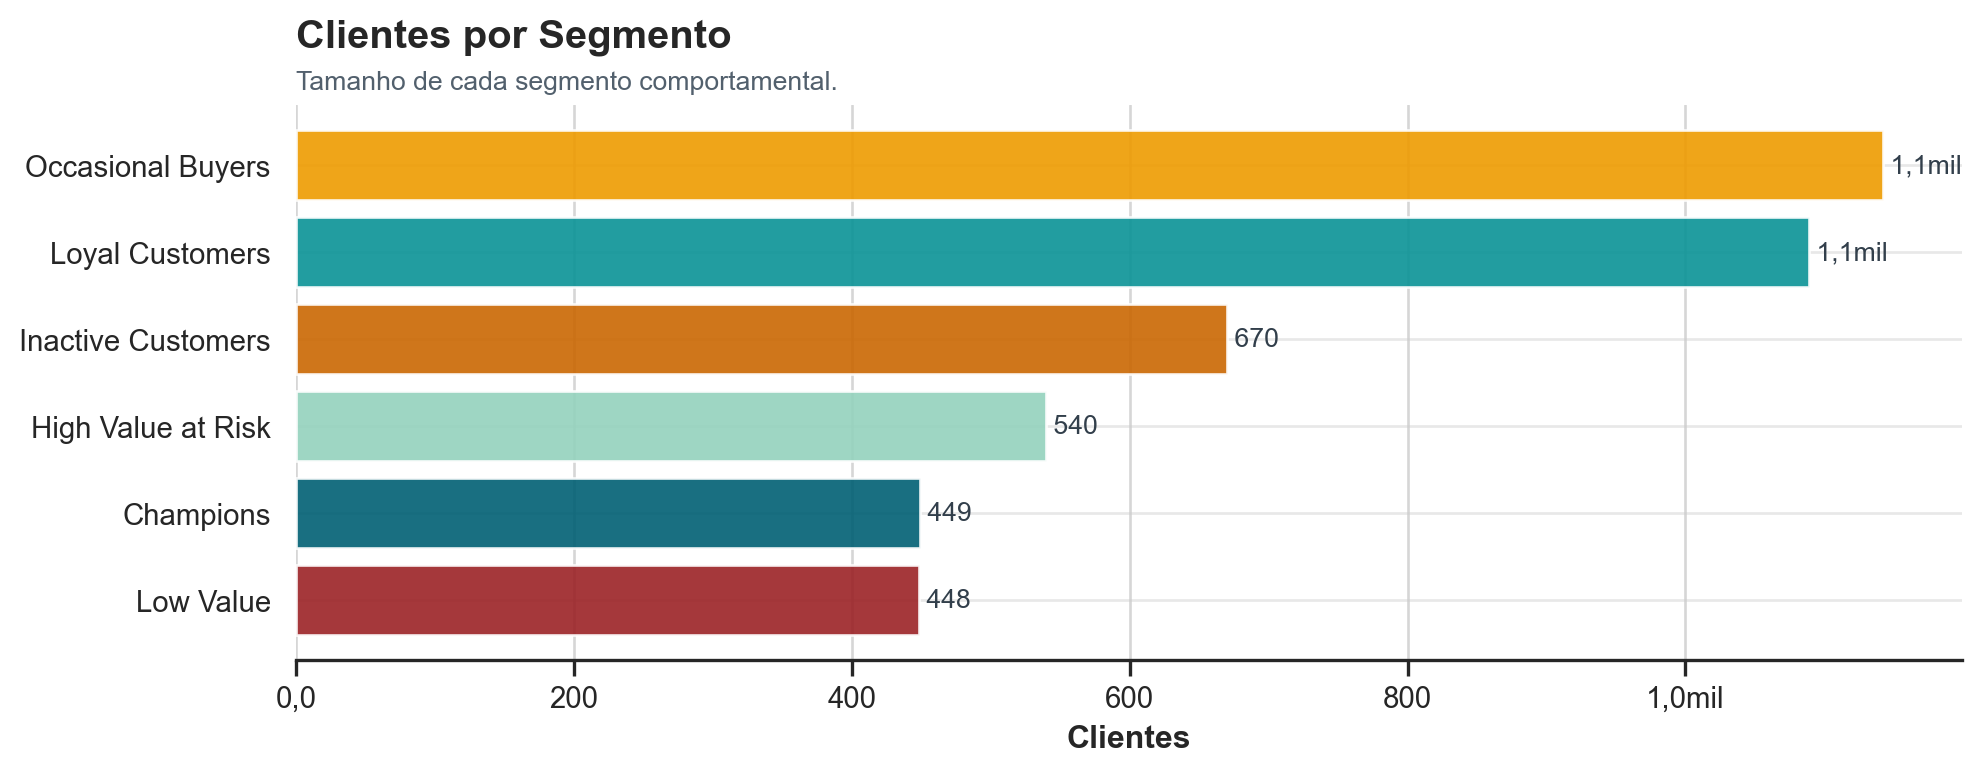

In [22]:
barh(
        profile.sort_values("Customers"),
        "SegmentName", "Customers",
        "Customers by Segment",
        "Size of each behavioural segment.",
        color_col="Cluster", cmap=cluster_colors,
)

<span style="color:steelblue; text-align: left">

## Next Best Action (Heurística)
</span>

Next Best Action transforma segmentação em decisão operacional. A primeira versão abaixo é uma recomendação heurística por segmento, útil para leitura gerencial inicial. Em seguida, o notebook evolui essa lógica para uma camada preditiva e prescritiva [Rust e Verhoef, 2005; Bertsimas e Kallus, 2019].


In [23]:
next_action_summary = rfm.groupby(
    ["SegmentName", "NextBestAction"], as_index=False
).agg(
    Customers=("Customer ID", "count"),
    TotalRevenue=("Monetary", "sum"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
).sort_values("TotalRevenue", ascending=False)
next_action_summary["RevenueShare"] = (
    next_action_summary["TotalRevenue"] / next_action_summary["TotalRevenue"].sum() * 100
)
display(next_action_summary)
display(
    rfm[[
        "Customer ID", "Cluster", "SegmentName",
        "Recency", "Frequency", "Monetary", "AverageTicket", "UniqueProducts",
        "NextBestAction",
    ]].head(10)
)

,SegmentName,NextBestAction,Customers,TotalRevenue,AvgRecency,AvgFrequency,RevenueShare
0,Champions,"Offer VIP program, early access and exclusive ...",449,5049204.49,16.16,17.41,56.66
4,Loyal Customers,Encourage cross-sell and bundles.,1089,1716135.50,36.36,5.37,19.26
1,High Value at Risk,Prioritize reactivation campaigns and personal...,540,1339679.91,87.92,2.18,15.03
5,Occasional Buyers,Second-purchase campaigns and low-cost coupons.,1142,496295.36,55.91,1.86,5.57
2,Inactive Customers,Targeted reactivation or low priority.,670,249271.17,271.27,1.35,2.80
3,Low Value,Low-cost marketing automation.,448,60821.47,137.26,1.49,0.68


,Customer ID,Cluster,SegmentName,Recency,Frequency,Monetary,AverageTicket,UniqueProducts,NextBestAction
0,12346,5,High Value at Risk,326,1,77183.60,77183.60,1,Prioritize reactivation campaigns and personal...
1,12347,1,Champions,2,7,4310.00,615.71,103,"Offer VIP program, early access and exclusive ..."
2,12348,5,High Value at Risk,75,4,1797.24,449.31,22,Prioritize reactivation campaigns and personal...
3,12349,5,High Value at Risk,19,1,1757.55,1757.55,73,Prioritize reactivation campaigns and personal...
4,12350,2,Inactive Customers,310,1,334.40,334.40,17,Targeted reactivation or low priority.
5,12352,4,Loyal Customers,36,8,2506.04,313.25,59,Encourage cross-sell and bundles.
6,12353,3,Low Value,204,1,89.00,89.00,4,Low-cost marketing automation.
7,12354,5,High Value at Risk,232,1,1079.40,1079.40,58,Prioritize reactivation campaigns and personal...
8,12355,2,Inactive Customers,214,1,459.40,459.40,13,Targeted reactivation or low priority.
9,12356,5,High Value at Risk,23,3,2811.43,937.14,53,Prioritize reactivation campaigns and personal...


<span style="color:steelblue; text-align: left">

## Da análise preditiva à análise prescritiva
</span>

A segmentação responde **quem são os clientes** e quais padrões comportamentais aparecem na base. O modelo supervisionado responde **qual é a probabilidade de recompra futura**. A camada prescritiva responde **qual ação maximiza o valor esperado** dado esse cenário.

Essa evolução aproxima o projeto do framework de Bertsimas e Kallus [Bertsimas e Kallus, 2019]: `X` representa os dados observados do cliente, `Y` representa a recompra futura, `z` representa a decisão de incentivo ou campanha, e a função objetivo escolhe a ação que maximiza lucro esperado.

Importante: a simulação abaixo **não estima efeito causal real** do incentivo. Os valores de uplift são hipóteses de negócio para mostrar a mecânica prescritiva. Em produção, o efeito incremental de cada campanha deveria ser validado por experimento A/B ou uplift modeling [Imbens e Rubin, 2015].


<span style="color:steelblue; text-align: left">

## 10. Camada preditiva — Probabilidade de recompra
</span>

Para evitar vazamento de dados, a base é dividida por tempo. As features são construídas apenas com compras anteriores à data de corte. O target `repurchase_90d` observa os 90 dias seguintes à data de corte e recebe valor 1 quando o cliente comprou novamente nesse período.

Esse target representa **recompra futura** em uma janela definida, não churn supervisionado clássico. A etapa preditiva ainda separa um hold-out independente antes da validação de modelos. Esse hold-out fica fora do treinamento e é usado depois para gerar probabilidades e alimentar a simulação financeira sem overfitting.

O K-Means segmenta comportamento observado; ele não estima diretamente a chance de recompra. Para criar a camada preditiva, um modelo supervisionado usa features pré-cutoff para estimar `prob_repurchase_90d`. A regressão logística é usada como baseline interpretável. A probabilidade usada na simulação prescritiva é calibrada com `calibrate()` de `src.prediction`, pois calibração reduz viés sistemático das probabilidades, essencial quando elas entram em cálculos financeiros.


In [24]:
def mode_or_unknown(series: pd.Series) -> str:
    mode = series.dropna().mode()
    return str(mode.iloc[0]) if not mode.empty else "Unknown"

prediction_horizon_days = PREDICTION_HORIZON_DAYS
cutoff_date    = clean_df["InvoiceDate"].max() - pd.Timedelta(days=prediction_horizon_days)
target_end_date = cutoff_date + pd.Timedelta(days=prediction_horizon_days)

feature_df = clean_df.loc[clean_df["InvoiceDate"] < cutoff_date].copy()
target_df  = clean_df.loc[
    (clean_df["InvoiceDate"] >= cutoff_date) &
    (clean_df["InvoiceDate"] <= target_end_date)
].copy()

predictive_features = feature_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (cutoff_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    QuantityTotal=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    CountryMode=("Country", mode_or_unknown),
).reset_index()

predictive_features["AverageTicket"] = np.where(
    predictive_features["Frequency"] > 0,
    predictive_features["Monetary"] / predictive_features["Frequency"],
    0.0,
)

future_buyers = set(target_df["Customer ID"].unique())
predictive_features["repurchase_90d"] = (
    predictive_features["Customer ID"].isin(future_buyers).astype(int)
)

target_summary = pd.DataFrame({
    "Metric": [
        "Cutoff date",
        "End of target window",
        "Customers with pre-cutoff features",
        "Buyers in future window",
    ],
    "Value": [
        cutoff_date.strftime("%Y-%m-%d"),
        target_end_date.strftime("%Y-%m-%d"),
        fmt(predictive_features["Customer ID"].nunique()),
        fmt(predictive_features["repurchase_90d"].sum()),
    ],
})
target_distribution = (
    predictive_features["repurchase_90d"]
    .value_counts().rename_axis("repurchase_90d")
    .reset_index(name="Count")
)
target_distribution["Percentage"] = (
    target_distribution["Count"] / target_distribution["Count"].sum() * 100
)
display(target_summary)
display(target_distribution.sort_values("repurchase_90d"))
display(predictive_features.head())

,Metric,Value
0,Cutoff date,2011-09-10
1,End of target window,2011-12-09
2,Customers with pre-cutoff features,3.370
3,Buyers in future window,1.921


,repurchase_90d,Count,Percentage
1,0,1449,43.00
0,1,1921,57.00


,Customer ID,Recency,Frequency,Monetary,QuantityTotal,UniqueProducts,CountryMode,AverageTicket,repurchase_90d
0,12346,235,1,77183.60,74215,1,United Kingdom,77183.60,0
1,12347,39,5,2790.86,1590,82,Iceland,558.17,1
2,12348,158,3,1487.24,2124,22,Finland,495.75,1
3,12350,219,1,334.40,197,17,Norway,334.40,0
4,12352,171,5,1561.81,254,26,Norway,312.36,1


,Model,Sample,ROC_AUC,Recall,Precision,Accuracy,BrierScore
1,RandomForestClassifier,Validation,0.75,0.57,0.79,0.67,0.21
0,LogisticRegression,Validation,0.74,0.59,0.78,0.67,0.21
2,GradientBoostingClassifier,Validation,0.74,0.69,0.72,0.67,0.20


,Model,Sample,BrierScore
0,Without calibration,Validation,0.21
1,Calibrated,Validation,0.20


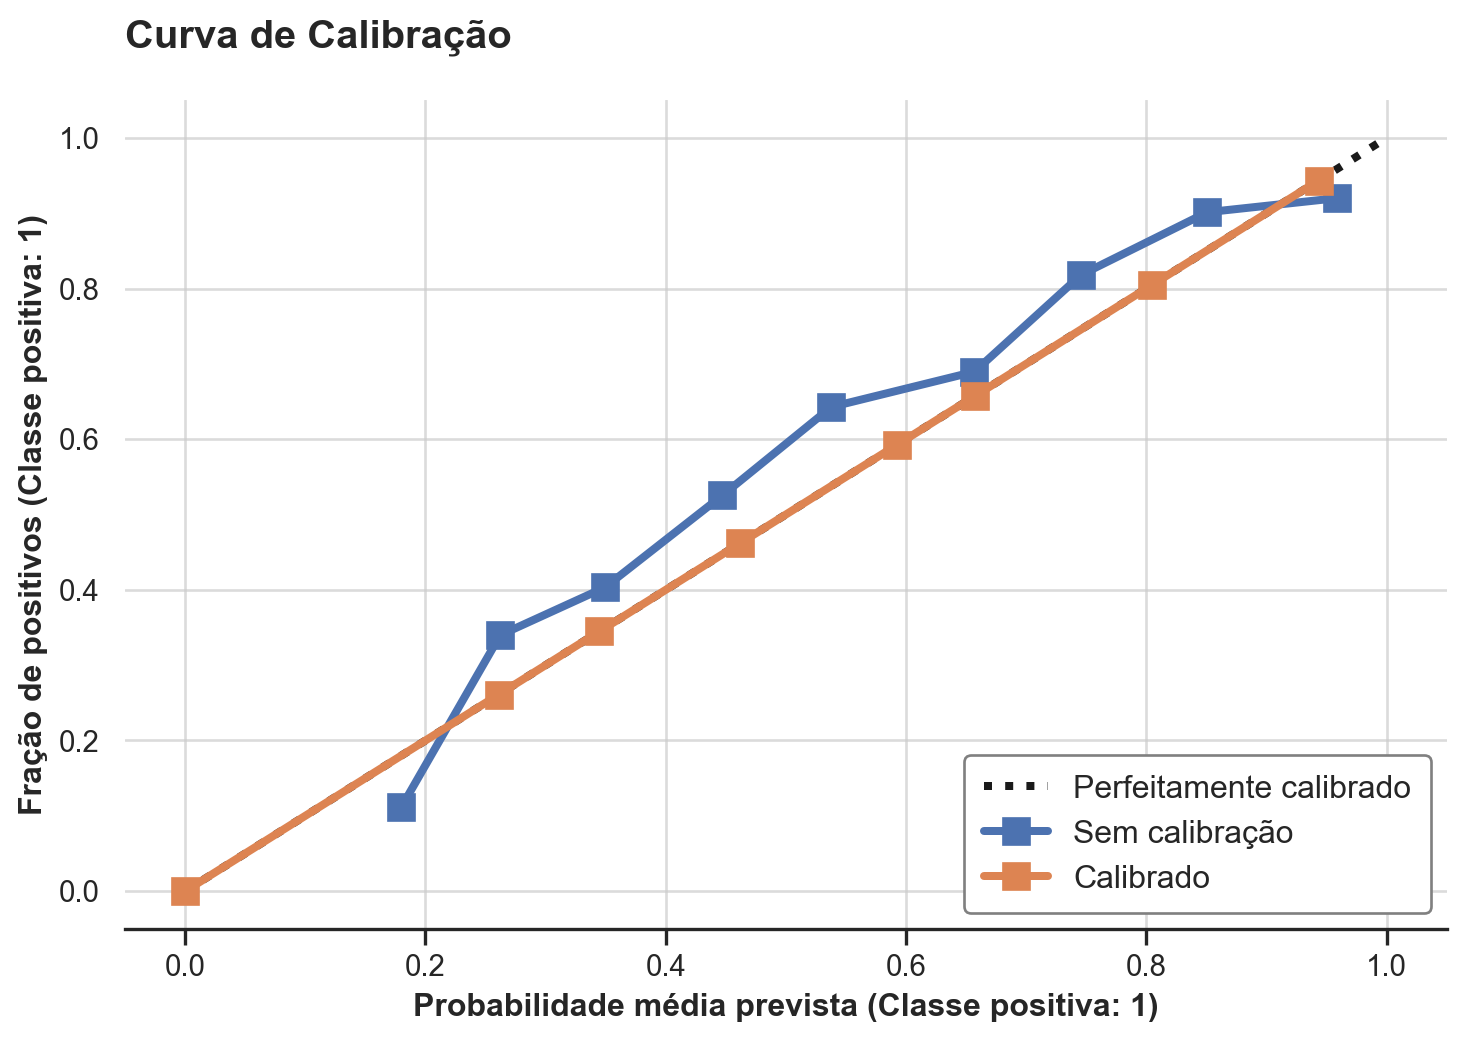

,Model,Sample,ROC_AUC,Recall,Precision,BrierScore
0,Without calibration,Hold-out,0.73,0.54,0.76,0.21
1,Calibrated,Hold-out,0.73,0.68,0.73,0.20


,Cluster,Recency,Frequency,Monetary,AverageTicket,UniqueProducts,TotalRevenue,Customers,RevenuePercentage,PredictiveSegment
3,3,18.26,14.99,10157.55,640.22,160.24,2011193.99,198,56.00,Champions
2,2,42.31,4.83,1436.66,312.25,72.35,640749.91,446,17.84,Loyal Customers
0,0,93.82,1.93,2473.16,1416.28,60.36,566353.22,229,15.77,High Value at Risk
1,1,60.17,1.83,422.80,254.70,25.06,212247.54,502,5.91,Occasional Buyers
4,4,206.73,1.24,329.73,274.29,20.32,135519.55,411,3.77,Inactive Customers
5,5,119.56,1.31,115.98,94.95,6.26,25283.45,218,0.70,Low Value


,Customer ID,PredictiveSegment,repurchase_90d,prob_repurchase_90d,Recency,Frequency,Monetary,AverageTicket
1558,15039,Champions,1,1.00,1,38,18513.80,487.21
846,13798,Champions,1,1.00,2,42,29161.14,694.31
654,13468,Champions,1,1.00,2,29,4739.02,163.41
2476,16684,Champions,1,1.00,42,18,33883.50,1882.42
1322,14606,Champions,1,1.00,3,71,9564.19,134.71
3132,17865,Champions,1,0.94,17,12,7017.34,584.78
1018,14092,Champions,1,0.94,9,10,2745.42,274.54
3034,17696,Loyal Customers,1,0.94,17,7,1915.59,273.66
3248,18075,Loyal Customers,1,0.94,15,8,1957.75,244.72
2301,16359,Loyal Customers,1,0.94,4,7,1411.23,201.60


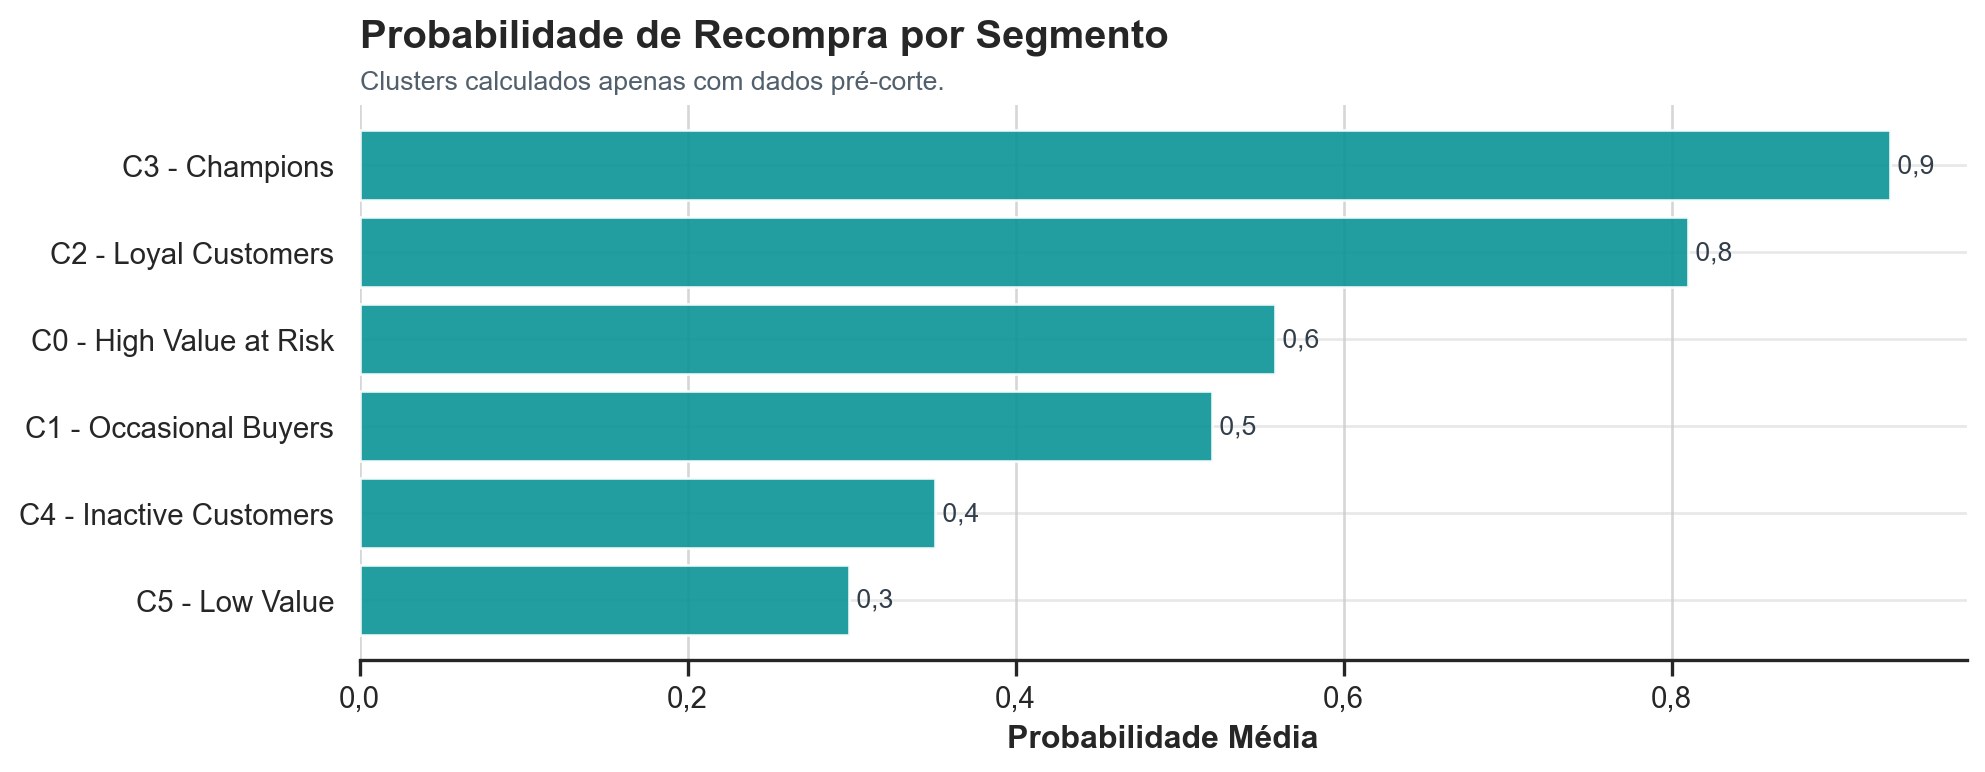

In [25]:
categorical_predictors = ["CountryMode"]
model_features = numeric_predictors + categorical_predictors

predictive_features = predictive_features.reset_index(drop=True)
modeling_df = predictive_features[
    ["Customer ID", "repurchase_90d"] + model_features
].copy().reset_index(drop=True)

X = modeling_df[model_features]
y = modeling_df["repurchase_90d"]
stratify_all = y if y.nunique() == 2 and y.value_counts().min() >= 2 else None

X_dev, X_hold, y_dev, y_hold = train_test_split(
    X, y,
    test_size=HOLDOUT_FRACTION,
    random_state=RANDOM_STATE,
    stratify=stratify_all,
)
stratify_dev = y_dev if y_dev.nunique() == 2 and y_dev.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X_dev, y_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=stratify_dev,
)

# ── Train candidate models ──────────────────────────────────────────────────
fitted_models = {}
metric_rows   = []
for model_name, estimator in make_model_specs(RANDOM_STATE).items():
    pipe = make_repurchase_pipeline(
        estimator,
        numeric_features=numeric_predictors,
        cluster_features=features,
        log_features=log_features,
        selected_k=selected_k,
    )
    pipe.fit(X_train, y_train)
    metric_rows.append(
        evaluate_classifier(model_name, "Validation", pipe, X_test, y_test)
    )
    fitted_models[model_name] = pipe

model_metrics = pd.DataFrame(metric_rows).sort_values("ROC_AUC", ascending=False)
display(model_metrics.round(4))

# ── Calibrate best model ────────────────────────────────────────────────────
baseline_model_name = "LogisticRegression"
baseline_pipeline   = fitted_models[baseline_model_name]
calibrated_model    = calibrate(baseline_pipeline, X_test, y_test)

calibration_metrics = pd.DataFrame([
    evaluate_classifier("Without calibration", "Validation",
                        baseline_pipeline, X_test, y_test),
    evaluate_classifier("Calibrated",          "Validation",
                        calibrated_model,      X_test, y_test),
])
display(calibration_metrics[["Model", "Sample", "BrierScore"]].round(4))

fig, ax = plt.subplots(figsize=(7.8, 5.6))
CalibrationDisplay.from_estimator(
    baseline_pipeline, X_test, y_test, n_bins=10, ax=ax, name=t("Without calibration")
)
CalibrationDisplay.from_estimator(
    calibrated_model, X_test, y_test, n_bins=10, ax=ax, name=t("Calibrated")
)
ax.set_title(t("Calibration Curve"), loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel(t("Mean predicted probability (Positive class: 1)"))
ax.set_ylabel(t("Fraction of positives (Positive class: 1)"))
legend = ax.get_legend()
if legend is not None:
    for text_obj in legend.get_texts():
        text_obj.set_text(t(text_obj.get_text()))
ax.grid(alpha=0.7)
plt.tight_layout()
plt.show()

# ── Hold-out evaluation ─────────────────────────────────────────────────────
holdout_metrics = pd.DataFrame([
    evaluate_classifier("Without calibration", "Hold-out",
                        baseline_pipeline, X_hold, y_hold),
    evaluate_classifier("Calibrated",          "Hold-out",
                        calibrated_model,      X_hold, y_hold),
])
display(holdout_metrics[["Model","Sample","ROC_AUC","Recall","Precision","BrierScore"]].round(4))

# ── Build holdout_predictions with segment labels ───────────────────────────
cluster_segmenter = KMeansClusterAdder(
    cluster_features=features,
    log_features=log_features,
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=20,
).fit(X_train)

train_clustered    = cluster_segmenter.transform(X_train)
train_profile_base = predictive_features.loc[X_train.index].copy()
train_profile_base["PredictiveCluster"] = (
    train_clustered["PredictiveCluster"].astype(int).to_numpy()
)

temporal_profile = train_profile_base.groupby("PredictiveCluster").agg(
    Cluster=("PredictiveCluster", "first"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    AverageTicket=("AverageTicket", "mean"),
    UniqueProducts=("UniqueProducts", "mean"),
    TotalRevenue=("Monetary", "sum"),
    Customers=("Customer ID", "count"),
).reset_index(drop=True)
temporal_profile["RevenuePercentage"] = (
    temporal_profile["TotalRevenue"] / temporal_profile["TotalRevenue"].sum() * 100
)

temporal_names = segment_names(temporal_profile)
validate_segment_names(temporal_profile, temporal_names)
temporal_profile["PredictiveSegment"] = temporal_profile["Cluster"].map(temporal_names)
display(temporal_profile.sort_values("TotalRevenue", ascending=False))

holdout_predictions = predictive_features.loc[X_hold.index].copy()
holdout_clustered   = cluster_segmenter.transform(X_hold)
holdout_predictions["PredictiveCluster"] = (
    holdout_clustered["PredictiveCluster"].astype(int).to_numpy()
)
holdout_predictions["PredictiveSegment"] = (
    holdout_predictions["PredictiveCluster"].map(temporal_names)
)
holdout_predictions["prob_repurchase_90d"] = calibrated_model.predict_proba(X_hold)[:, 1]

# ── Merge probability into rfm for CRM export ───────────────────────────────
rfm = rfm.drop(columns=["prob_repurchase_90d"], errors="ignore").merge(
    holdout_predictions[["Customer ID", "prob_repurchase_90d"]],
    on="Customer ID",
    how="left",
)

display(
    holdout_predictions[[
        "Customer ID", "PredictiveSegment",
        "repurchase_90d", "prob_repurchase_90d",
        "Recency", "Frequency", "Monetary", "AverageTicket",
    ]].sort_values("prob_repurchase_90d", ascending=False).head(10)
)

# Repurchase probability by segment chart
prob_by_cluster = holdout_predictions.groupby(
    ["PredictiveCluster", "PredictiveSegment"], as_index=False
).agg(
    AvgProb=("prob_repurchase_90d", "mean"),
    Customers=("Customer ID", "count"),
)
prob_by_cluster["ClusterSegment"] = (
    "C" + prob_by_cluster["PredictiveCluster"].astype(str)
    + " - " + prob_by_cluster["PredictiveSegment"]
)

barh(
    prob_by_cluster.sort_values("AvgProb"),
    "ClusterSegment", "AvgProb",
    "Repurchase Probability by Segment",
    "Clusters computed only from pre-cutoff data.",
    PALETTE[1],
)

<span style="color:steelblue; text-align: left">

### **Insight (recompra por segmento):** 

</span>

A probabilidade média de recompra varia de forma relevante entre segmentos, confirmando sinal preditivo no comportamento segmentado.
Segmentos com maior probabilidade tendem a ações de proteção de margem, enquanto grupos de menor probabilidade exigem gasto seletivo.
A dispersão reforça o uso de incentivos individualizados em vez de campanha uniforme.
Essas probabilidades alimentam diretamente a otimização de lucro esperado na camada prescritiva.


<span style="color:steelblue; text-align: left">

## 11. Camada prescritiva — Simulação de incentivos
</span>

A camada prescritiva avalia ações possíveis `z` para cada cliente. Cada ação tem um custo de incentivo e um uplift heurístico que varia por segmento. O lucro esperado é: `adjusted_prob = min(base_prob + base_uplift × segment_multiplier, 1)`, `expected_revenue = adjusted_prob × Monetary`, `expected_profit = expected_revenue × MARGIN_RATE − incentive_cost`.

Os valores em `INCENTIVE_CATALOGUE` e `SEGMENT_UPLIFT_MULTIPLIER` são hipóteses de simulação de negócio, não efeitos causais estimados. Substitua por resultados de experimentos A/B ou modelo de uplift antes do uso em produção.


In [26]:
simulation    = simulate_actions(
    holdout_predictions,
    prob_col="prob_repurchase_90d",
    segment_col="PredictiveSegment",
    revenue_col="Monetary",
)
prescriptive_df = select_best_action(simulation)

# Merge back contextual columns needed for recommendations and CRM export
prescriptive_df = prescriptive_df.merge(
    holdout_predictions[[
        "Customer ID", "PredictiveSegment", "PredictiveCluster",
        "prob_repurchase_90d", "Monetary", "AverageTicket",
    ]],
    on="Customer ID",
    how="left",
)

action_summary = prescriptive_df.groupby(
    ["BestAction", "RecommendedAction"], as_index=False
).agg(
    Customers=("Customer ID", "count"),
    TotalExpectedProfit=("ExpectedProfit", "sum"),
    TotalIncrementalProfit=("IncrementalProfit", "sum"),
    AvgProb=("prob_repurchase_90d", "mean"),
).sort_values("TotalIncrementalProfit", ascending=False)

display(action_summary.round(4))
display(
    simulation[[
        "Customer ID", "Action", "incentive_cost",
        "AdjustedProb", "ExpectedRevenue", "ExpectedProfit", "IncrementalProfit",
    ]].head(12)
)

,BestAction,RecommendedAction,Customers,TotalExpectedProfit,TotalIncrementalProfit,AvgProb
0,High Incentive,High Incentive — $10 voucher,235,71296.00,10069.42,0.62
2,Medium Incentive,Medium Incentive — $5 voucher,103,82595.03,4662.36,0.75
1,Low Incentive,Low Incentive — $2 voucher,15,648.24,1.75,0.34
3,No Action,No Action,153,37266.94,0.00,0.38


,Customer ID,Action,incentive_cost,AdjustedProb,ExpectedRevenue,ExpectedProfit,IncrementalProfit
0,14373,No Action,0.00,0.00,0.00,0.00,0.00
1,14373,Low Incentive,2.00,0.02,1.38,-1.52,-1.52
2,14373,Medium Incentive,5.00,0.04,3.22,-3.87,-3.87
3,14373,High Incentive,10.00,0.07,5.51,-8.07,-8.07
4,16008,No Action,0.00,0.35,48.24,16.88,0.00
5,16008,Low Incentive,2.00,0.36,50.74,15.76,-1.12
6,16008,Medium Incentive,5.00,0.39,54.08,13.93,-2.95
7,16008,High Incentive,10.00,0.42,58.26,10.39,-6.49
8,17616,No Action,0.00,0.41,235.20,82.32,0.00
9,17616,Low Incentive,2.00,0.43,245.48,83.92,1.60


<span style="color:steelblue; text-align: left">

## 12. Otimização com restrição orçamentária
</span>

A decisão ótima por cliente ignora que o orçamento de marketing é finito. Nesta etapa, a recomendação prescritiva é submetida a `BUDGET_TOTAL` e uma seleção gulosa prioriza clientes com maior lucro incremental esperado até consumir o orçamento disponível. Essa alocação gulosa é uma heurística — para uma otimização exata use Programação Linear Inteira (ILP).

**Nota sobre o escopo:** A simulação de incentivos e a alocação de budget operam sobre o hold-out set (≈15% da base total), que é o subconjunto para o qual o modelo gerou probabilidades em dados nunca vistos durante o treinamento. Em produção, o modelo calibrado seria aplicado sobre toda a base ativa.

A seção também compara uma função objetivo baseada em margem (usando `MARGIN_RATE`) e três cenários: sem ação, campanha uniforme e prescrição individual.


Na prÁtica, a alocação gulosa costuma capturar cerca de 85-95% da solução ótima de ILP para instancias deste porte. Para otimização exata, veja a formulação ILP listada em Melhorias Futuras.

,Metric,Value
0,Simulation scope,Hold-out set
1,Total budget,"10.000,00"
2,Budget used,"2.895,00"
3,Remaining budget,"7.105,00"
4,Clientes exportados,353
5,Expected incremental profit,"14.733,53"


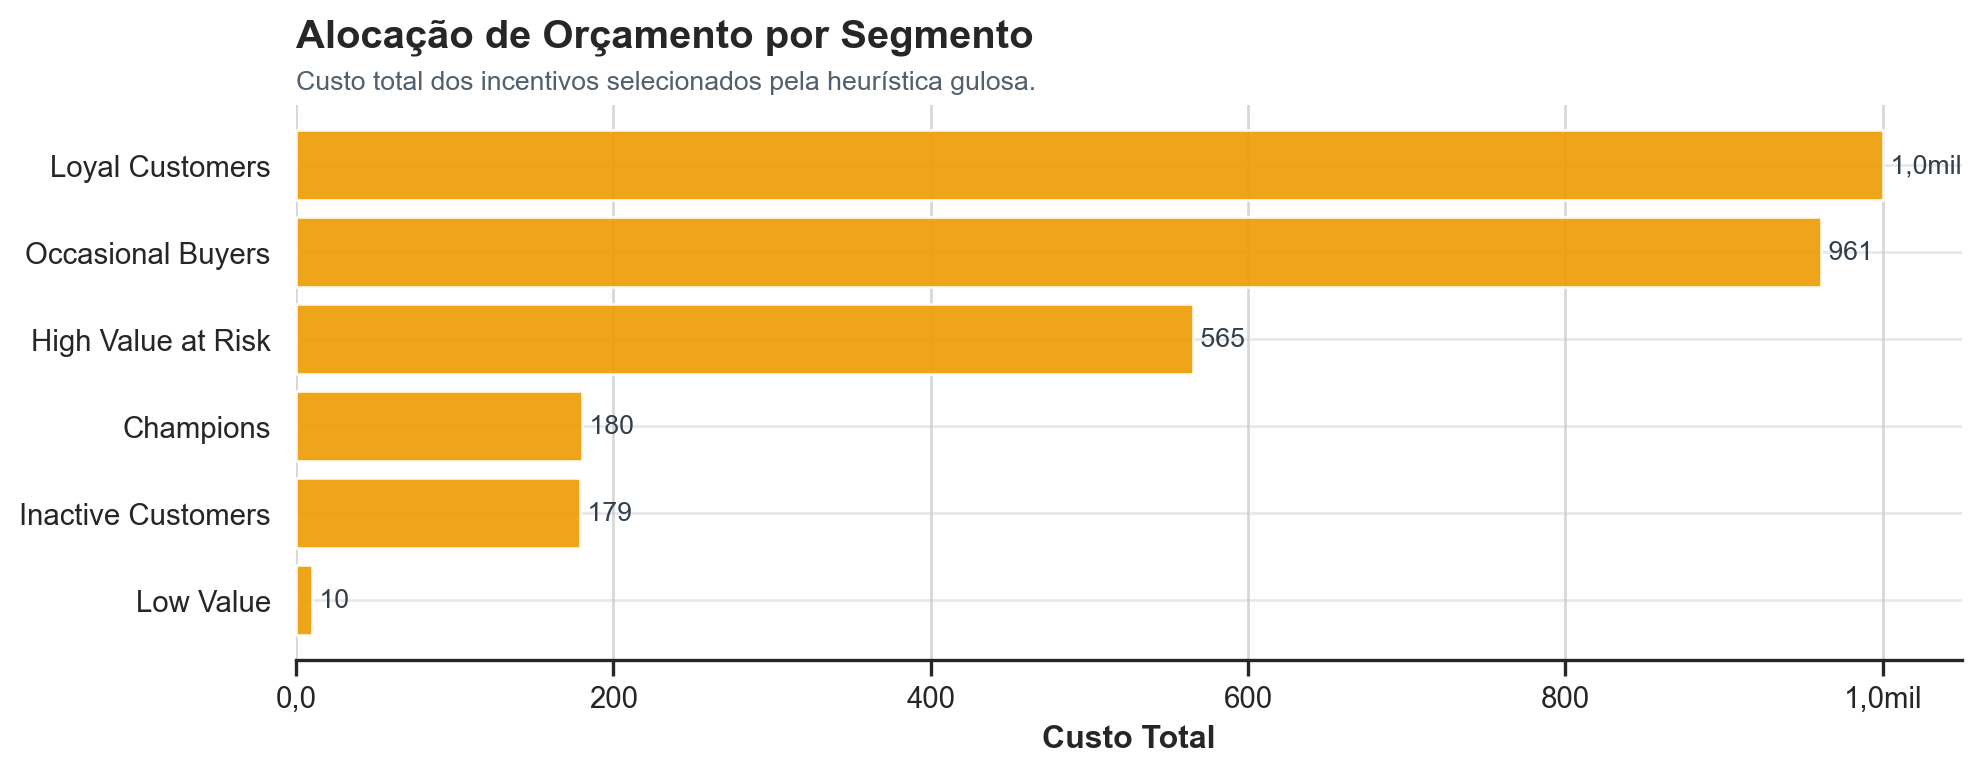

,Metric,Value
0,Customers evaluated,506
1,Customers with changed action,134
2,Percentage with changed action,26.5%


,Scenario,TotalProfit,TotalCost,GainVsBaseline,ROI
0,A — No action,177072.67,0.00,0.00,NaN
1,B — Uniform campaign (medium),187347.77,2530.00,10275.10,4.06
2,C — Prescription per customer,42604.44,2046.00,-134468.23,-65.72


,BudgetPercentile,Budget,IncrementalProfit,CustomersServed,ROI
0,25%,708.98,9331.37,84.00,13.20
1,50%,1417.96,13082.56,170.00,9.23
2,75%,2186.02,14457.05,250.00,6.62
3,100%,2895.00,14733.53,353.00,5.09


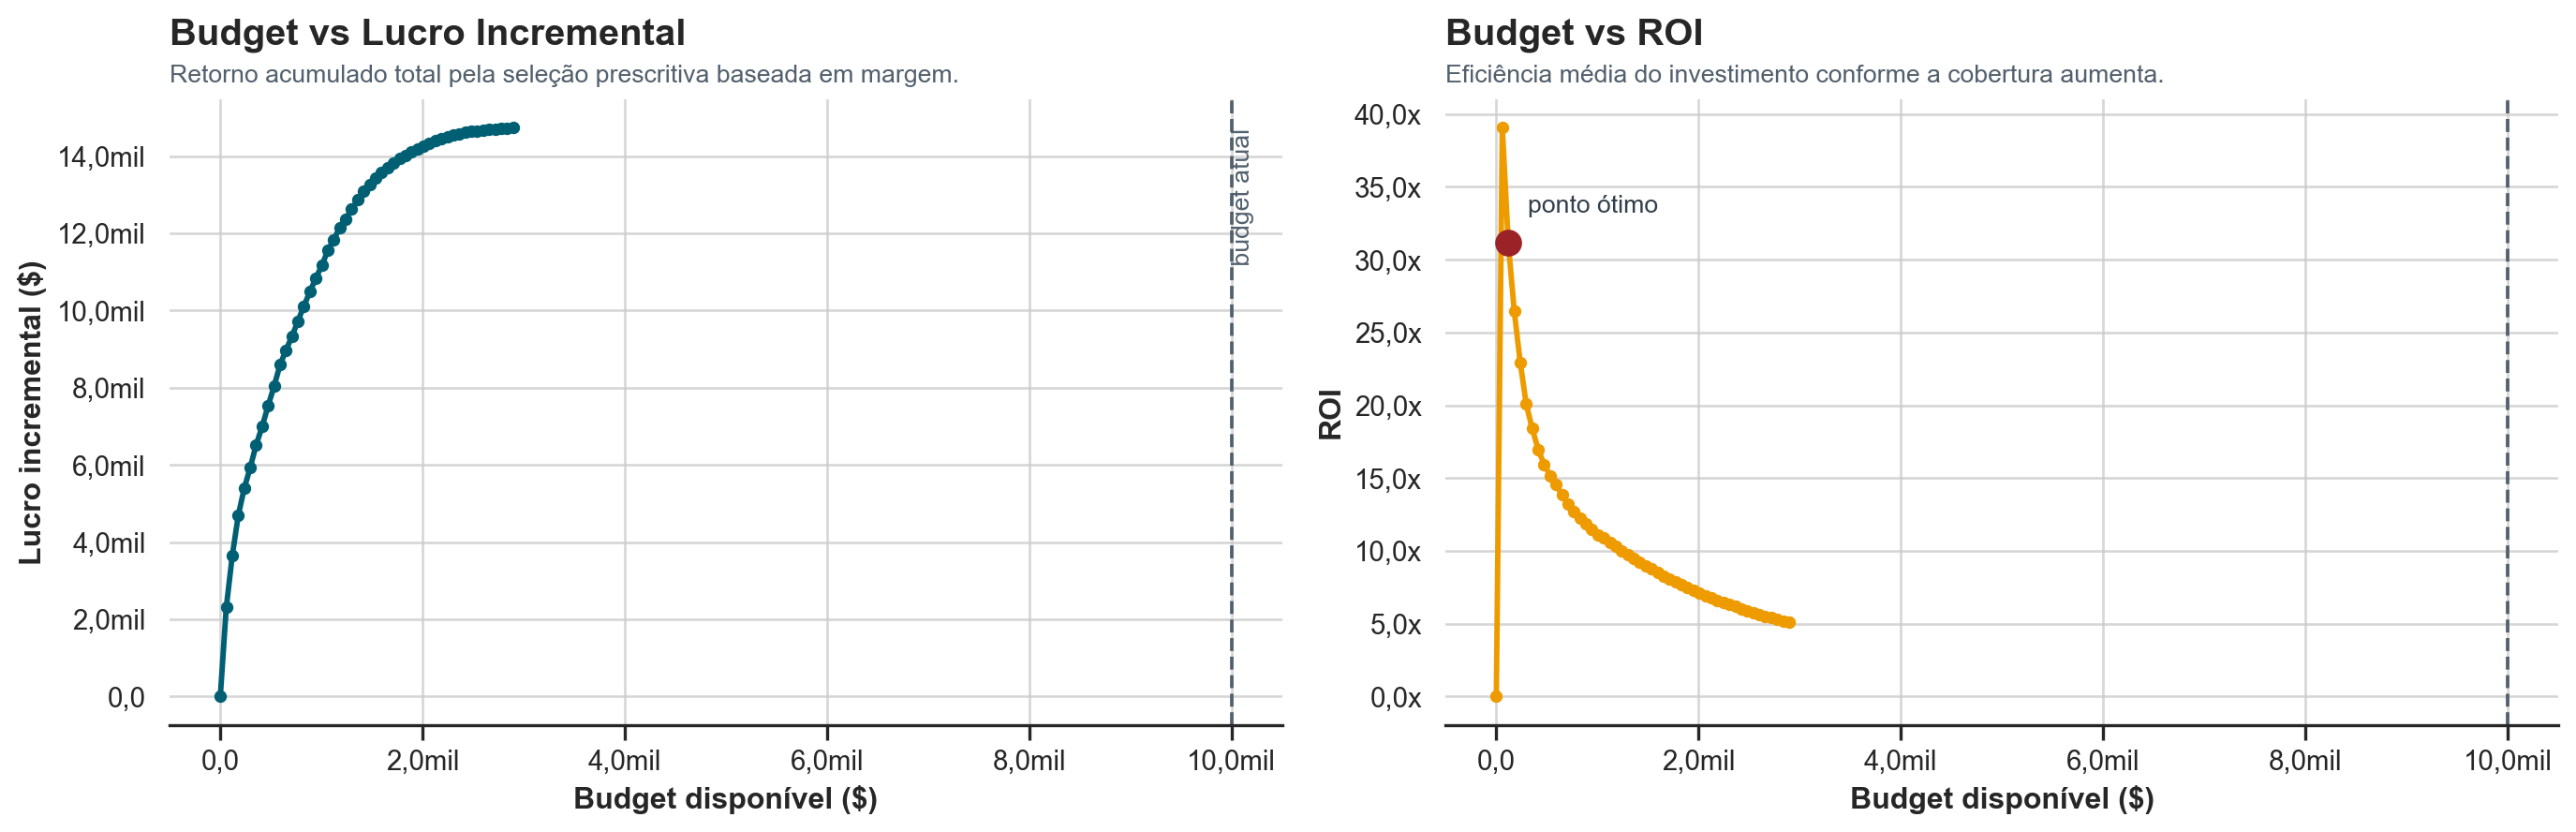

In [27]:
# ── Budget allocation ─────────────────────────────────────────────────────
prescriptive_with_budget = allocate_budget(prescriptive_df, budget=BUDGET_TOTAL)

budget_summary = prescriptive_with_budget.groupby("PredictiveSegment", as_index=False).agg(
    Customers=("Customer ID", "count"),
    Allocated=("BudgetAllocated", "sum"),
    TotalCost=("incentive_cost", lambda x: x[prescriptive_with_budget.loc[x.index, "BudgetAllocated"]].sum()),
    TotalIncrementalProfit=("IncrementalProfit", lambda x: x[prescriptive_with_budget.loc[x.index, "BudgetAllocated"]].sum()),
).sort_values("TotalIncrementalProfit", ascending=False)

allocated_df = prescriptive_with_budget.loc[prescriptive_with_budget["BudgetAllocated"]]
remaining_budget = BUDGET_TOTAL - allocated_df["incentive_cost"].sum()
budget_overview = pd.DataFrame({
    "Metric": [
        "Simulation scope",
        "Total budget",
        "Budget used",
        "Remaining budget",
        t("Customers exported: {}").split(":")[0],
        "Expected incremental profit",
    ],
    "Value": [
        "Hold-out set",
        fmt(BUDGET_TOTAL, 2),
        fmt(allocated_df["incentive_cost"].sum(), 2),
        fmt(remaining_budget, 2),
        fmt(len(allocated_df)),
        fmt(allocated_df["IncrementalProfit"].sum(), 2),
    ],
})
display(budget_overview)

barh(
    budget_summary.sort_values("TotalCost"),
    "PredictiveSegment", "TotalCost",
    "Budget Allocation by Segment",
    "Total cost of incentives selected by the greedy heuristic.",
    PALETTE[3],
)

# ── Margin-based objective comparison ─────────────────────────────────────
decision_simulation = simulation.merge(
    holdout_predictions[["Customer ID", "prob_repurchase_90d", "AverageTicket"]],
    on="Customer ID",
    how="left",
)
decision_simulation["expected_margin"] = (
    decision_simulation["AdjustedProb"] * decision_simulation["AverageTicket"] * MARGIN_RATE
)
decision_simulation["expected_profit_margin"] = (
    decision_simulation["expected_margin"] - decision_simulation["incentive_cost"]
)
margin_best_idx = decision_simulation.groupby("Customer ID")["expected_profit_margin"].idxmax()
prescriptive_margin_df = decision_simulation.loc[margin_best_idx].copy()
prescriptive_margin_df = prescriptive_margin_df.rename(columns={
    "Action": "BestActionMargin",
    "expected_profit_margin": "BestMarginProfit",
})

margin_comparison = prescriptive_df[["Customer ID", "BestAction"]].merge(
    prescriptive_margin_df[["Customer ID", "BestActionMargin"]],
    on="Customer ID",
    how="left",
)
margin_comparison["action_changed"] = (
    margin_comparison["BestAction"] != margin_comparison["BestActionMargin"]
)
display(pd.DataFrame({
    "Metric": ["Customers evaluated", "Customers with changed action",
               "Percentage with changed action"],
    "Value": [
        len(margin_comparison),
        int(margin_comparison["action_changed"].sum()),
        f"{margin_comparison['action_changed'].mean()*100:.1f}%",
    ],
}))

# ── Scenario comparison ───────────────────────────────────────────────────
UNIFORM_UPLIFT = 0.07
UNIFORM_COST   = 5.00

scenario_a_profit = (
    holdout_predictions["prob_repurchase_90d"] *
    holdout_predictions["Monetary"] * MARGIN_RATE
).sum()
scenario_b_profit = (
    (holdout_predictions["prob_repurchase_90d"] + UNIFORM_UPLIFT).clip(upper=1) *
    holdout_predictions["Monetary"] * MARGIN_RATE - UNIFORM_COST
).sum()
scenario_c_profit = prescriptive_margin_df["BestMarginProfit"].sum()

scenario_summary = pd.DataFrame({
    "Scenario": ["A — No action", "B — Uniform campaign (medium)", "C — Prescription per customer"],
    "TotalProfit": [scenario_a_profit, scenario_b_profit, scenario_c_profit],
    "TotalCost":   [0.0, UNIFORM_COST * len(holdout_predictions),
                    prescriptive_margin_df["incentive_cost"].sum()],
})
scenario_summary["GainVsBaseline"] = (
    scenario_summary["TotalProfit"] - scenario_summary.loc[0, "TotalProfit"]
)
scenario_summary["ROI"] = np.where(
    scenario_summary["TotalCost"] > 0,
    scenario_summary["GainVsBaseline"] / scenario_summary["TotalCost"],
    np.nan,
)
display(scenario_summary.round(2))

# ── Budget curve ───────────────────────────────────────────────────────────
budget_curve_df, budget_breakpoints = build_budget_curve(prescriptive_df)
display(budget_breakpoints.round(2))

positive_curve = budget_curve_df.loc[budget_curve_df["ActualCost"] > 0].copy()
if positive_curve.empty:
    optimal_budget_point = budget_curve_df.iloc[[0]].copy()
else:
    positive_curve["ROI_Delta"] = positive_curve["ROI"].diff()
    if positive_curve["ROI_Delta"].notna().any():
        optimal_idx = positive_curve["ROI_Delta"].idxmin()
    else:
        optimal_idx = positive_curve["ROI"].idxmax()
    optimal_budget_point = budget_curve_df.loc[[optimal_idx]].copy()

budget_curves(budget_curve_df, BUDGET_TOTAL, optimal_budget_point)


<span style="color:steelblue; text-align: left">

### Interpretacao (budget e cenários):

</span>
A alocação de budget concentra gasto onde o lucro incremental é maior, gerando perfil não linear de ROI conforme a cobertura aumenta.
A comparação de cenários tende a mostrar prescrição individual superando campanha uniforme sob o mesmo orçamento.
Na prática, a heurística gulosa costuma capturar cerca de 85-95% da solução ótima de ILP para instâncias deste porte.
Para otimização exata, veja a formulação ILP listada em Melhorias Futuras.


<span style="color:steelblue; text-align: left">

## 13. Análise de sensibilidade
</span>

Modelos preditivos não são perfeitos. Esta seção simula o que acontece com o lucro esperado total quando as probabilidades reais diferem das estimadas em até ±15 pontos percentuais. Um modelo robusto deve ser lucrativo mesmo sob perturbações realistas. Se o lucro esperado entrar em território negativo com um deslocamento de apenas -5pp, a política de incentivos é frágil demais para produção.


,NoiseDelta,TotalIncrementalProfit
0,-0.15,140520.04
1,-0.10,151736.13
2,-0.05,162954.09
3,0.00,174177.67
4,0.05,183829.17
5,0.10,190356.67
6,0.15,195979.86


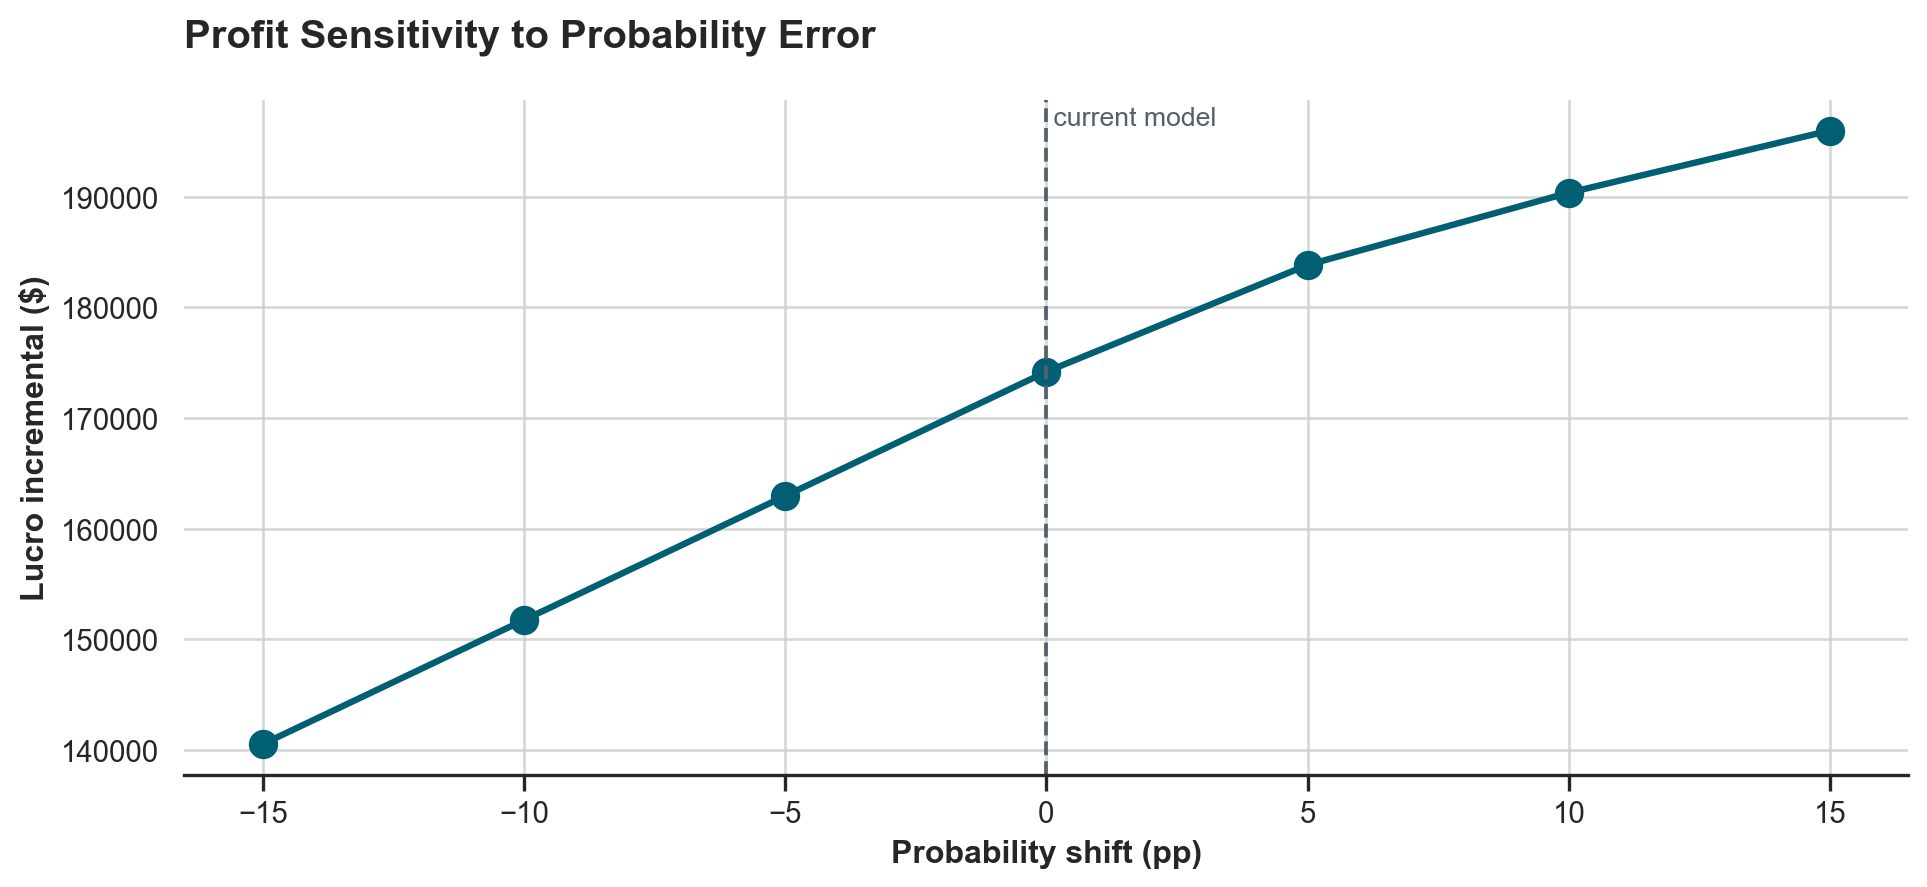

In [24]:
prescriptive_for_sensitivity = prescriptive_df[
    ["Customer ID", "incentive_cost"]
].merge(
    holdout_predictions[["Customer ID", "prob_repurchase_90d", "Monetary"]],
    on="Customer ID",
    how="left",
)
sensitivity_df = sensitivity_analysis(prescriptive_for_sensitivity)
display(sensitivity_df.round(2))

fig, ax = plt.subplots(figsize=(10.2, 4.8))
ax.plot(
    sensitivity_df["NoiseDelta"] * 100,
    sensitivity_df["TotalIncrementalProfit"],
    marker="o", linewidth=2.4, color=PALETTE[0],
)
ax.axvline(0, color="#52606D", linestyle="--", linewidth=1.4)
ax.text(0, sensitivity_df["TotalIncrementalProfit"].max(),
        " current model", ha="left", va="bottom", fontsize=10, color="#52606D")
ax.set_title("Profit Sensitivity to Probability Error",
             loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel("Probability shift (pp)")
ax.set_ylabel(t("Incremental profit ($)"))
ax.grid(alpha=0.8)
plt.tight_layout()
plt.show()


<span style="color:steelblue; text-align: left">

### Insight (sensibilidade):

</span>

O lucro incremental total cai quando as probabilidades sao perturbadas para baixo, quantificando risco de decisão sob erro de modelo.
A inclinação ao redor de 0 pp mostra a sensibilidade da economia da campanha a desvios de calibração.
Se o lucro se mantém positivo sob choques negativos moderados, a política e mais robusta para produção.
Esse teste de estresse complementa estimativas pontuais com uma visão de resiliência.


<span style="color:steelblue; text-align: left">

## Decisão "não agir": maturidade de negócio
</span>

Modelos ingênuos enviam campanhas para todos. Modelos maduros sabem quando **não agir** é a melhor decisão. Esta seção quantifica explicitamente os clientes para quem nenhum incentivo gera retorno positivo, e quanto budget é preservado por essa decisão.


,Group,Customers,PercentageOfBase,BudgetSaved,BudgetInvested,TotalIncrementalProfit
0,No incentive,153,30.24,765.00,0.00,0.00
1,With incentive,353,69.76,0.00,2895.00,14733.53


,PredictiveSegment,Customers,BudgetSaved
1,Inactive Customers,76,380.00
2,Low Value,45,225.00
3,Occasional Buyers,27,135.00
0,Champions,5,25.00


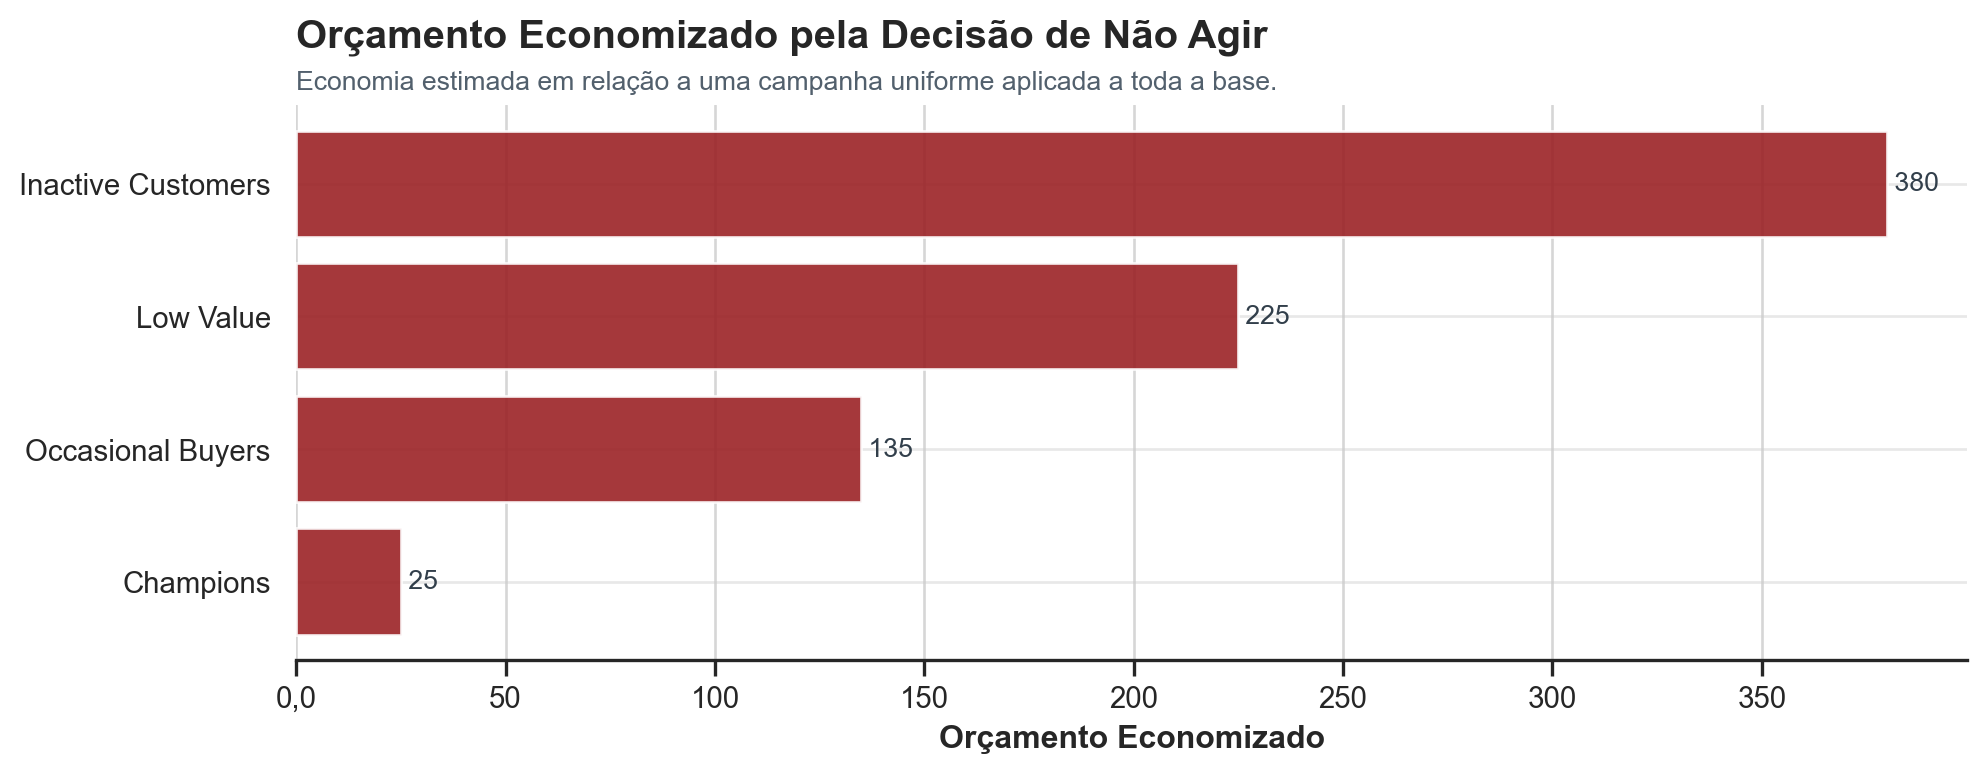

In [25]:
no_action_clients = prescriptive_df.loc[
    (prescriptive_df["BestAction"] == "No Action") |
    (prescriptive_df["IncrementalProfit"] <= 0)
].copy()
action_clients = prescriptive_df.loc[
    (prescriptive_df["BestAction"] != "No Action") &
    (prescriptive_df["IncrementalProfit"] > 0)
].copy()

UNIFORM_COST_LOCAL = 5.00
no_action_clients["budget_avoided"] = UNIFORM_COST_LOCAL
action_clients["budget_avoided"]    = 0.0

no_action_summary = pd.DataFrame({
    "Group": ["No incentive", "With incentive"],
    "Customers": [len(no_action_clients), len(action_clients)],
    "PercentageOfBase": [
        len(no_action_clients) / len(prescriptive_df) * 100,
        len(action_clients) / len(prescriptive_df) * 100,
    ],
    "BudgetSaved":  [no_action_clients["budget_avoided"].sum(), 0],
    "BudgetInvested": [0, action_clients["incentive_cost"].sum()],
    "TotalIncrementalProfit": [
        no_action_clients["IncrementalProfit"].sum(),
        action_clients["IncrementalProfit"].sum(),
    ],
})
display(no_action_summary.round(2))

no_action_by_segment = (
    no_action_clients.groupby("PredictiveSegment", as_index=False)
    .agg(Customers=("Customer ID", "count"),
         BudgetSaved=("budget_avoided", "sum"))
    .sort_values("Customers", ascending=False)
)
display(no_action_by_segment.round(2))
barh(
    no_action_by_segment.sort_values("BudgetSaved"),
    "PredictiveSegment", "BudgetSaved",
    "Budget Saved by Do-Nothing Decision",
    "Estimated savings against a uniform campaign applied to the entire base.",
    PALETTE[5],
)

<span style="color:steelblue; text-align: left">

## 14. Next Best Action — Recomendações finais
</span>

A decisão final testa todas as ações disponíveis para cada cliente e seleciona aquela com maior `ExpectedProfit`. O ganho incremental compara a melhor ação contra `No Action`. A função `build_recommendation()` de `src.prescriptive` traduz cada decisão em uma frase executiva respeitando o idioma ativo via `t()`.


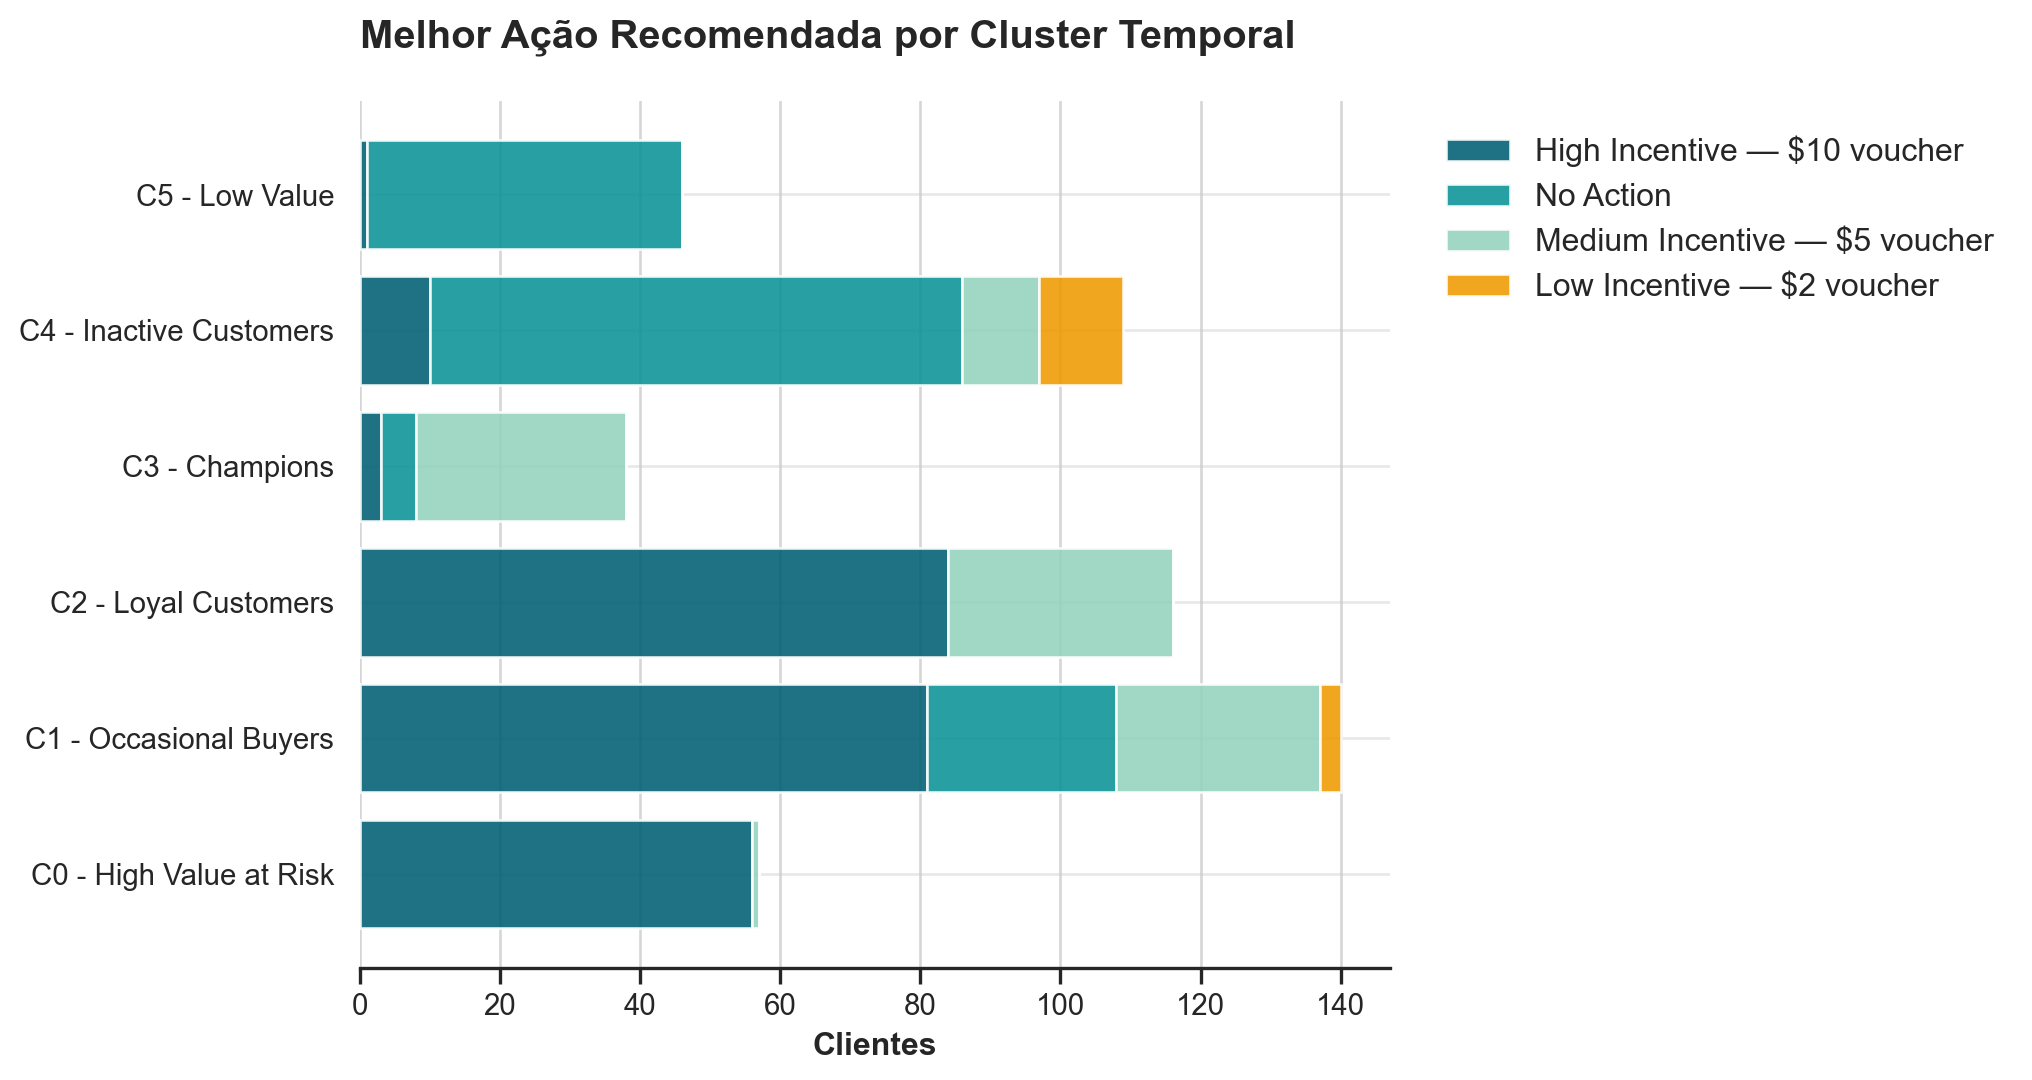

In [28]:
prescriptive_df["PrescriptiveNextBestAction"] = prescriptive_df.apply(
    build_recommendation, axis=1
)
prescriptive_df["ClusterSegment"] = (
    "C" + prescriptive_df["PredictiveCluster"].astype(str)
    + " - " + prescriptive_df["PredictiveSegment"]
)

# Distribution of best action by cluster
cluster_action_counts = pd.crosstab(
    prescriptive_df["ClusterSegment"],
    prescriptive_df["RecommendedAction"],
)
cluster_order = (
    holdout_predictions.groupby(["PredictiveCluster", "PredictiveSegment"])
    .size().reset_index(name="n")
    .sort_values("PredictiveCluster")
)
cluster_order["ClusterSegment"] = (
    "C" + cluster_order["PredictiveCluster"].astype(str)
    + " - " + cluster_order["PredictiveSegment"]
)
cluster_action_counts = cluster_action_counts.reindex(
    cluster_order["ClusterSegment"].tolist()
).fillna(0)

action_order = list(prescriptive_df["RecommendedAction"].value_counts().index)
action_palette_map = {a: PALETTE[i % len(PALETTE)] for i, a in enumerate(action_order)}

fig, ax = plt.subplots(figsize=(10.8, 5.8))
left = np.zeros(len(cluster_action_counts))
for action in action_order:
    if action not in cluster_action_counts.columns:
        continue
    values = cluster_action_counts[action].to_numpy()
    ax.barh(cluster_action_counts.index, values, left=left,
            color=action_palette_map[action], alpha=0.88, label=action)
    left += values
ax.set_title(t("Best Recommended Action by Temporal Cluster"),
            loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel(t("Customers"))
ax.grid(axis="x", alpha=0.8)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


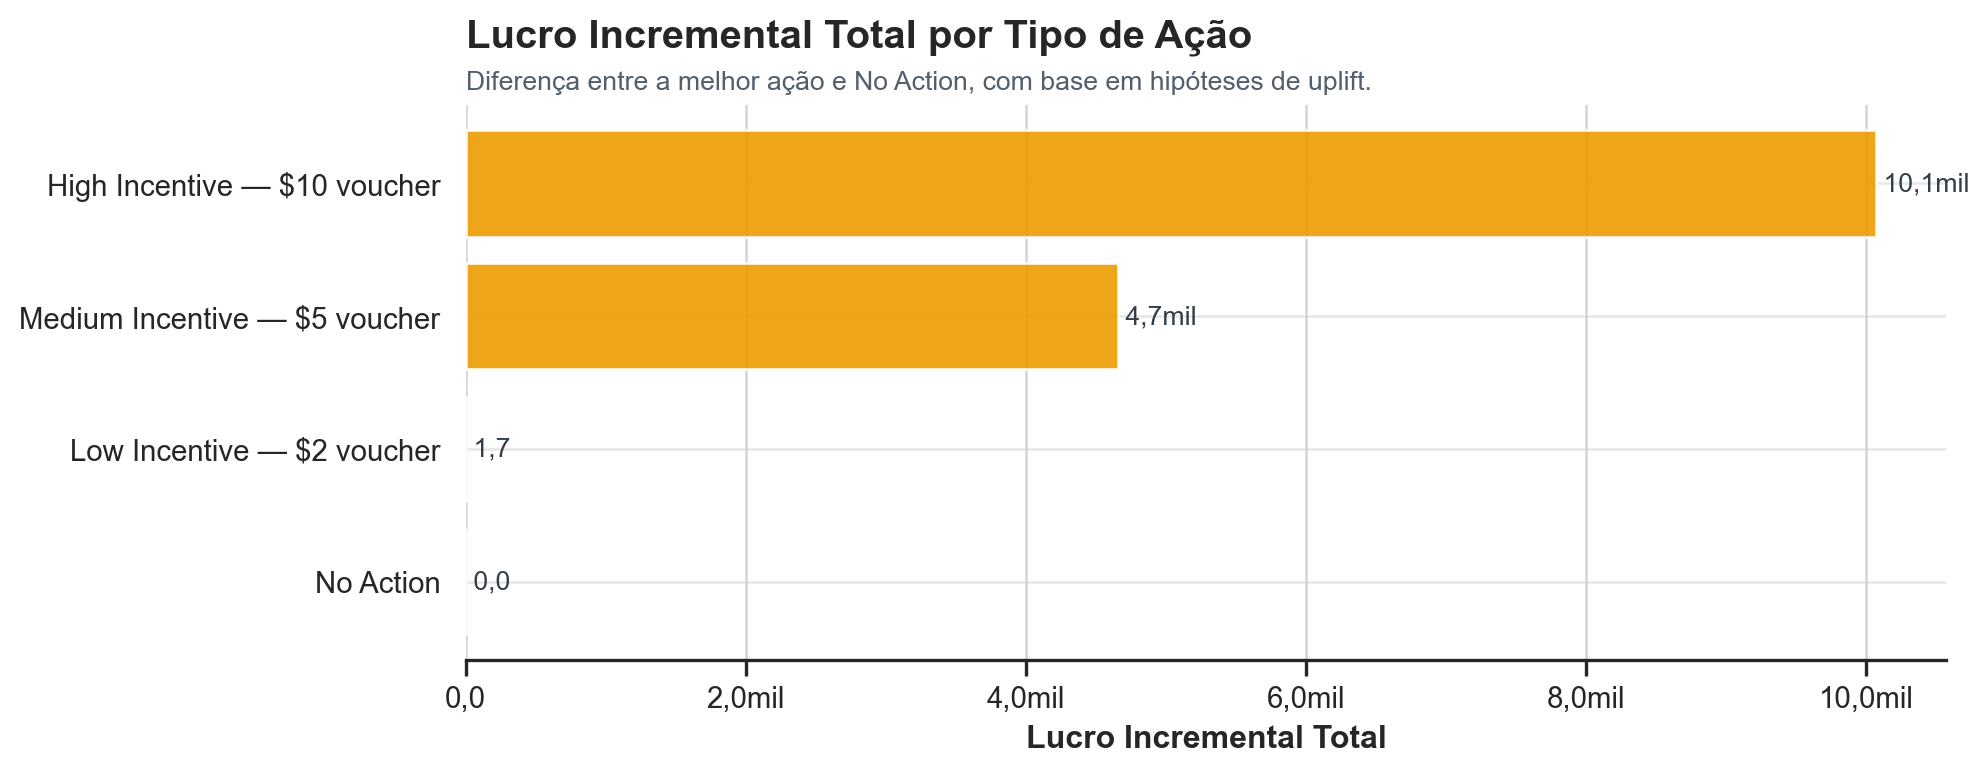

In [29]:
barh(
    action_summary.sort_values("TotalIncrementalProfit"),
    "RecommendedAction", "TotalIncrementalProfit",
    "Total Incremental Profit by Action Type",
    "Difference between best action and No Action, based on uplift hypotheses.",
    PALETTE[3],
)

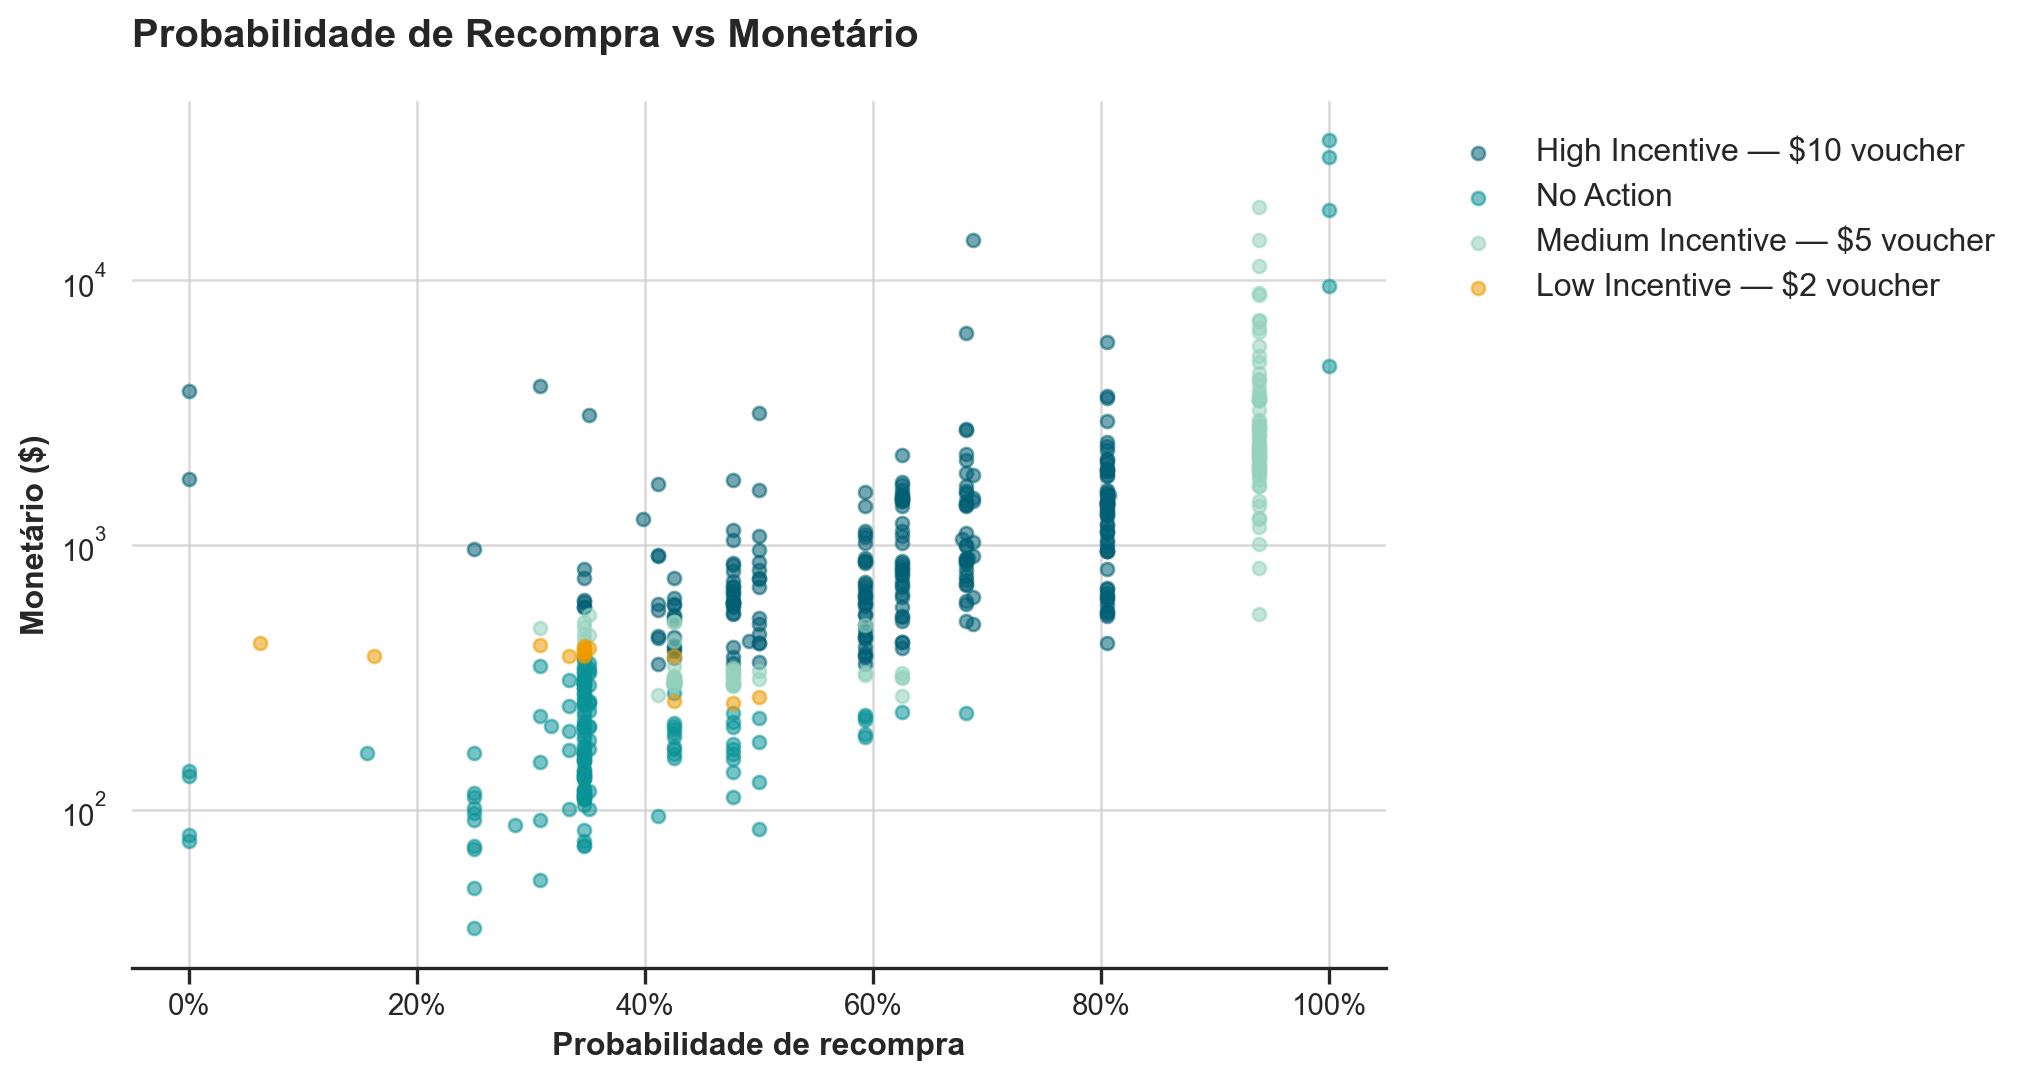

,Customer ID,PredictiveSegment,prob_repurchase_90d,BestAction,RecommendedAction,ExpectedProfit,IncrementalProfit,PrescriptiveNextBestAction
29,12744,Champions,0.69,High Incentive,High Incentive — $10 voucher,4006.66,586.90,Máxima prioridade de retenção com campanha agr...
51,13081,Champions,0.94,Medium Incentive,Medium Incentive — $5 voucher,6599.54,399.36,Priorizar relacionamento com medium incentive ...
400,17107,High Value at Risk,0.68,High Incentive,High Incentive — $10 voucher,1845.92,335.84,Máxima prioridade de retenção com campanha agr...
471,17857,Champions,0.94,Medium Incentive,Medium Incentive — $5 voucher,4984.08,300.45,Priorizar relacionamento com medium incentive ...
262,15513,Champions,0.94,Medium Incentive,Medium Incentive — $5 voucher,3968.25,238.26,Priorizar relacionamento com medium incentive ...
491,18092,Champions,0.81,High Incentive,High Incentive — $10 voucher,1884.59,235.76,Máxima prioridade de retenção com campanha agr...
13,12435,High Value at Risk,0.31,High Incentive,High Incentive — $10 voucher,635.76,207.25,Máxima prioridade de retenção com campanha agr...
31,12755,High Value at Risk,0.00,High Incentive,High Incentive — $10 voucher,198.13,198.13,Máxima prioridade de retenção com campanha agr...
227,15159,Champions,0.94,Medium Incentive,Medium Incentive — $5 voucher,3134.49,187.21,Priorizar relacionamento com medium incentive ...
136,14062,Champions,0.94,Medium Incentive,Medium Incentive — $5 voucher,3075.23,183.59,Priorizar relacionamento com medium incentive ...


In [30]:
# Scatter: prob vs monetary coloured by action
fig, ax = plt.subplots(figsize=(10.8, 5.8))
for action in action_order:
    group = prescriptive_df.loc[prescriptive_df["RecommendedAction"] == action]
    if group.empty:
        continue
    ax.scatter(group["prob_repurchase_90d"], group["Monetary"],
                s=24, alpha=0.55, color=action_palette_map[action], label=action)
ax.set_title(t("Repurchase Probability vs Monetary"),
                loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel(t("Repurchase probability"))
ax.set_ylabel(t("Monetary ($)"))
ax.set_yscale("log")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(alpha=0.7)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(
    prescriptive_df[[
        "Customer ID", "PredictiveSegment", "prob_repurchase_90d",
        "BestAction", "RecommendedAction", "ExpectedProfit",
        "IncrementalProfit", "PrescriptiveNextBestAction",
    ]].sort_values("IncrementalProfit", ascending=False).head(10)
)

<span style="color:steelblue; text-align: left">

## 15. Export operacional para CRM
</span>

O arquivo `crm_next_best_action.csv` consolida, para cada cliente do hold-out,
o segmento, a ação recomendada, o lucro esperado e a descrição executiva da
Next Best Action. A coluna `priority_rank` ordena clientes globalmente por
lucro incremental — rank 1 é o cliente que mais retorno gera se receber um incentivo.

O arquivo está pronto para importação direta em ferramentas de CRM, automação
de e-mail marketing ou priorização de fila de atendimento.


In [31]:
crm_output = build_crm_export(rfm, prescriptive_df)

EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
crm_output.to_csv(EXPORT_PATH, index=False, sep=";", decimal=",", encoding="utf-8-sig")

print(t("Export generated: {}").format(EXPORT_PATH))
print(t("Customers exported: {}").format(fmt(len(crm_output))))
print(t("Segments covered: {}").format(crm_output["segment_name"].nunique()))

display(crm_output.head(10))
display(
    crm_output.groupby("segment_name", as_index=False).agg(
        Customers=("customer_id", "count"),
        TotalIncrementalProfit=("incremental_profit", "sum"),
        MinPriority=("priority_rank", "min"),
        MaxPriority=("priority_rank", "max"),
    ).sort_values("TotalIncrementalProfit", ascending=False)
)

Exportação gerada: outputs\crm_next_best_action.csv
Clientes exportados: 506
Segmentos cobertos: 6


,customer_id,segment_name,recency_days,frequency,monetary_total,average_ticket,prob_repurchase_90d,best_action_code,recommended_campaign,expected_profit,expected_profit_no_action,incremental_profit,crm_action_description,priority_rank
0,12744,Champions,52,7,21279.29,3039.90,0.69,High Incentive,High Incentive — $10 voucher,4006.66,3419.76,586.90,Máxima prioridade de retenção com campanha agr...,1
1,13081,Champions,12,11,28337.38,2576.13,0.94,Medium Incentive,Medium Incentive — $5 voucher,6599.54,6200.18,399.36,Priorizar relacionamento com medium incentive ...,2
2,17107,Champions,33,6,10815.43,1802.57,0.68,High Incentive,High Incentive — $10 voucher,1845.92,1510.08,335.84,Máxima prioridade de retenção com campanha agr...,3
3,17857,Champions,4,23,26879.04,1168.65,0.94,Medium Incentive,Medium Incentive — $5 voucher,4984.08,4683.63,300.45,Priorizar relacionamento com medium incentive ...,4
4,15513,Champions,33,19,14758.22,776.75,0.94,Medium Incentive,Medium Incentive — $5 voucher,3968.25,3729.99,238.26,Priorizar relacionamento com medium incentive ...,5
5,18092,Champions,2,11,9068.26,824.39,0.81,High Incentive,High Incentive — $10 voucher,1884.59,1648.83,235.76,Máxima prioridade de retenção com campanha agr...,6
6,15159,Champions,2,30,18641.01,621.37,0.94,Medium Incentive,Medium Incentive — $5 voucher,3134.49,2947.28,187.21,Priorizar relacionamento com medium incentive ...,9
7,14062,Champions,10,12,10464.85,872.07,0.94,Medium Incentive,Medium Incentive — $5 voucher,3075.23,2891.65,183.59,Priorizar relacionamento com medium incentive ...,10
8,16656,Champions,22,15,8625.80,575.05,0.94,Medium Incentive,Medium Incentive — $5 voucher,2485.84,2338.34,147.50,Priorizar relacionamento com medium incentive ...,14
9,17865,Champions,31,20,10526.32,526.32,0.94,Medium Incentive,Medium Incentive — $5 voucher,2451.07,2305.70,145.37,Priorizar relacionamento com medium incentive ...,15


,segment_name,Customers,TotalIncrementalProfit,MinPriority,MaxPriority
0,Champions,63,5927.31,1,358
4,Loyal Customers,155,4699.56,13,465
1,High Value at Risk,58,3486.74,7,360
5,Occasional Buyers,84,382.13,175,506
2,Inactive Customers,108,230.75,140,416
3,Low Value,38,7.05,275,451


<span style="color:steelblue; text-align: left">

## 16. Melhorias implementadas
</span>

- **Problema 1:** `PredictiveCluster` passou a ser gerado dentro do `Pipeline`, com `KMeans.fit()` apenas no treino e `predict()` para validação e hold-out.
- **Problema 2:** foi criado um hold-out independente de 15%, e a simulação financeira usa probabilidades geradas em dados não vistos pelo modelo.
- **Problema 3:** o uplift deixou de ser uniforme e passou a variar por segmento via `SEGMENT_UPLIFT_MULTIPLIER`.
- **Problema 4:** as probabilidades foram calibradas com `calibrate()` de `src.prediction` e avaliadas com reliability diagram e Brier Score.
- **Problema 5:** foi adicionada uma alocação de budget com restrição orçamentária via `allocate_budget()` e `build_budget_curve()`.
- **Problema 6:** a nomeação automática dos segmentos agora possui validações de sanidade com `validate_segment_names()`.
- **P1:** Índice resetado antes dos splits; `check_is_fitted` no transformer; assertion de alinhamento.
- **P2:** Escopo do hold-out documentado na simulação de budget com contexto de produção.
- **P3:** Export CSV operacional via `build_crm_export()` com `priority_rank` para uso direto em CRM.
- **P4:** Parâmetros operacionais centralizados em `src.config`.
- **I1:** função de lucro recalculada com `MARGIN_RATE`, comparando ações otimizadas por receita versus margem.
- **I2:** análise executiva de cenários compara sem ação, campanha uniforme e prescrição individual.
- **I3:** sensibilidade financeira simula deslocamentos de probabilidade de -15pp a +15pp via `sensitivity_analysis()`.
- **I4:** decisão `No Action` foi quantificada como economia de budget frente a uma campanha uniforme.
- **I5:** curva de budget mostra lucro incremental, ROI e breakpoints executivos via `build_budget_curve()` e `budget_curves()`.


<span style="color:steelblue; text-align: left">

## 17. Conclusão
</span>

Este projeto evoluiu de uma análise tradicional de segmentação de clientes para uma estrutura mais avançada de análise prescritiva, capaz de apoiar decisões de marketing orientadas por dados.

Inicialmente, a análise concentrou-se na compreensão do comportamento de compra dos clientes por meio de métricas RFM e clusterização com K-Means, permitindo identificar diferentes perfis de clientes com características comportamentais e valores comerciais distintos. Embora a segmentação, por si só, já forneça insights estratégicos relevantes, o projeto foi expandido além da análise descritiva ao incorporar uma camada supervisionada de previsão baseada na probabilidade futura de recompra.

Utilizando uma abordagem de validação temporal, o modelo estimou a probabilidade de recompra dentro de um horizonte futuro, reduzindo riscos de vazamento de dados (*data leakage*) e criando um cenário mais próximo da realidade de negócio. Essa camada preditiva transformou o projeto de um exercício estático de segmentação em um pipeline analítico orientado ao futuro.

Posteriormente, o projeto foi elevado para uma perspectiva de análise prescritiva inspirada no framework proposto por Bertsimas e Kallus em *From Predictive to Prescriptive Analytics*. Em vez de apenas prever resultados, o notebook passou a simular possíveis ações de marketing e estimar seus impactos econômicos esperados por meio de cálculos de lucro esperado.

Ao combinar variáveis comportamentais dos clientes, probabilidade de recompra, incentivos simulados de marketing, receita esperada, custos de campanha e restrições orçamentárias, o pipeline tornou-se capaz de recomendar a ação economicamente mais vantajosa para cada cliente ou segmento.

Uma das principais contribuições do projeto é a transição de *"O que provavelmente irá acontecer?"* para *"Qual decisão deve ser tomada?"* — a principal diferença entre análise preditiva e análise prescritiva.

Embora os valores de *uplift* utilizados nas simulações sejam hipóteses heurísticas e não estimativas causais reais, a estrutura construída estabelece uma base sólida para futuras evoluções envolvendo testes A/B, *uplift modeling*, inferência causal, *reinforcement learning* e otimização sob incerteza.


<span style="color:steelblue; text-align: left">

## 18. Referências
</span>

- **[Bertsimas e Kallus, 2019]** Bertsimas, D., e Kallus, N. (2019). *From Predictive to Prescriptive Analytics*. Management Science. https://doi.org/10.1287/mnsc.2018.3253
- **[Chen, 2012]** Chen, D. (2012). *Online Retail II* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5CG6D
- **[Chen, Sain e Guo, 2012]** Chen, D., Sain, S. L., e Guo, K. (2012). *Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining*. Journal of Database Marketing & Customer Strategy Management, 19, 197-208. https://doi.org/10.1057/dbm.2012.17
- **[Fader, Hardie e Lee, 2005]** Fader, P. S., Hardie, B. G. S., e Lee, K. L. (2005). *RFM and CLV: Using Iso-Value Curves for Customer Base Analysis*. Journal of Marketing Research, 42(4), 415-430. https://doi.org/10.1509/jmkr.2005.42.4.415
- **[Hastie, Tibshirani e Friedman, 2009]** Hastie, T., Tibshirani, R., e Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7
- **[Imbens e Rubin, 2015]** Imbens, G. W., e Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences: An Introduction*. Cambridge University Press. https://doi.org/10.1017/CBO9781139025751
- **[Jain, 2010]** Jain, A. K. (2010). *Data clustering: 50 years beyond K-means*. Pattern Recognition Letters, 31(8), 651-666. https://doi.org/10.1016/j.patrec.2009.09.011
- **[Kuhn e Johnson, 2013]** Kuhn, M., e Johnson, K. (2013). *Applied Predictive Modeling*. Springer. https://doi.org/10.1007/978-1-4614-6849-3
- **[Lloyd, 1982]** Lloyd, S. (1982). *Least squares quantization in PCM*. IEEE Transactions on Information Theory, 28(2), 129-137. https://doi.org/10.1109/TIT.1982.1056489
- **[MacQueen, 1967]** MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability, 1, 281-297.
- **[Rousseeuw, 1987]** Rousseeuw, P. J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis*. Journal of Computational and Applied Mathematics, 20, 53-65. https://doi.org/10.1016/0377-0427(87)90125-7
- **[Rust e Verhoef, 2005]** Rust, R. T., e Verhoef, P. C. (2005). *Optimizing the Marketing Interventions Mix in Intermediate-Term CRM*. Marketing Science, 24(3), 477-489. https://doi.org/10.1287/mksc.1040.0107
- **[Tukey, 1977]** Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
- **[Wedel e Kamakura, 2000]** Wedel, M., e Kamakura, W. A. (2000). *Market Segmentation: Conceptual and Methodological Foundations* (2nd ed.). Springer. https://doi.org/10.1007/978-1-4615-4651-1
